# 상관분석과 예측의 기초

### 학습목표

1. **상관계수**의 수학적 정의와 해석 방법을 이해함
2. **단순선형회귀**의 원리와 최소제곱법을 이해함
3. **sklearn**을 활용하여 예측 모델을 구현하고 평가함
4. 실제 **공공데이터**를 활용한 상관분석 및 회귀분석을 수행함

## 환경 설정

본 강의에서 사용할 라이브러리를 설치하고 임포트함.

In [4]:
# 필요 라이브러리 설치 (필요시 주석 해제)
#!pip install numpy pandas matplotlib seaborn scikit-learn scipy

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 8.0/8.0 MB 62.1 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [

In [5]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 머신러닝 라이브러리
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# 한글 폰트 설정 -> 이전 차시에도 언급하였지만, 이 부분이 시각화 스타일 이후에 나타나도록 구성할 것.
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

# 경고 무시
import warnings
warnings.filterwarnings('ignore')

print("환경 설정 완료")

환경 설정 완료


---

# 1. 상관분석의 수학적 기초

---

## 1.1 상관분석이란?

### 정의

**상관분석(Correlation Analysis)** 은 두 연속형 변수 간의 **선형적 관계의 강도와 방향**을 수치화하는 통계적 방법임.

### 제조 현장에서의 활용 사례

| 질문 | 변수 X | 변수 Y | 기대 관계 |
|------|--------|--------|----------|
| 온도가 높아지면 불량률도 높아지는가? | 공정 온도 | 불량률 | 양의 상관 |
| 가동 시간이 길수록 생산량이 많은가? | 가동 시간 | 생산량 | 양의 상관 |
| 작업자 교육시간이 늘면 실수가 줄어드는가? | 교육 시간 | 실수 건수 | 음의 상관 |
| 습도가 제품 품질에 영향을 주는가? | 습도 | 품질 점수 | 불확실 |

### 상관관계의 세 가지 유형

1. **양의 상관(Positive Correlation)**: X가 증가할 때 Y도 증가하는 경향
2. **음의 상관(Negative Correlation)**: X가 증가할 때 Y가 감소하는 경향
3. **무상관(No Correlation)**: X와 Y 사이에 선형적 관계가 없음

## 1.2 상관관계의 시각적 이해

다양한 상관관계 패턴을 산점도로 시각화하여 직관적으로 이해함.

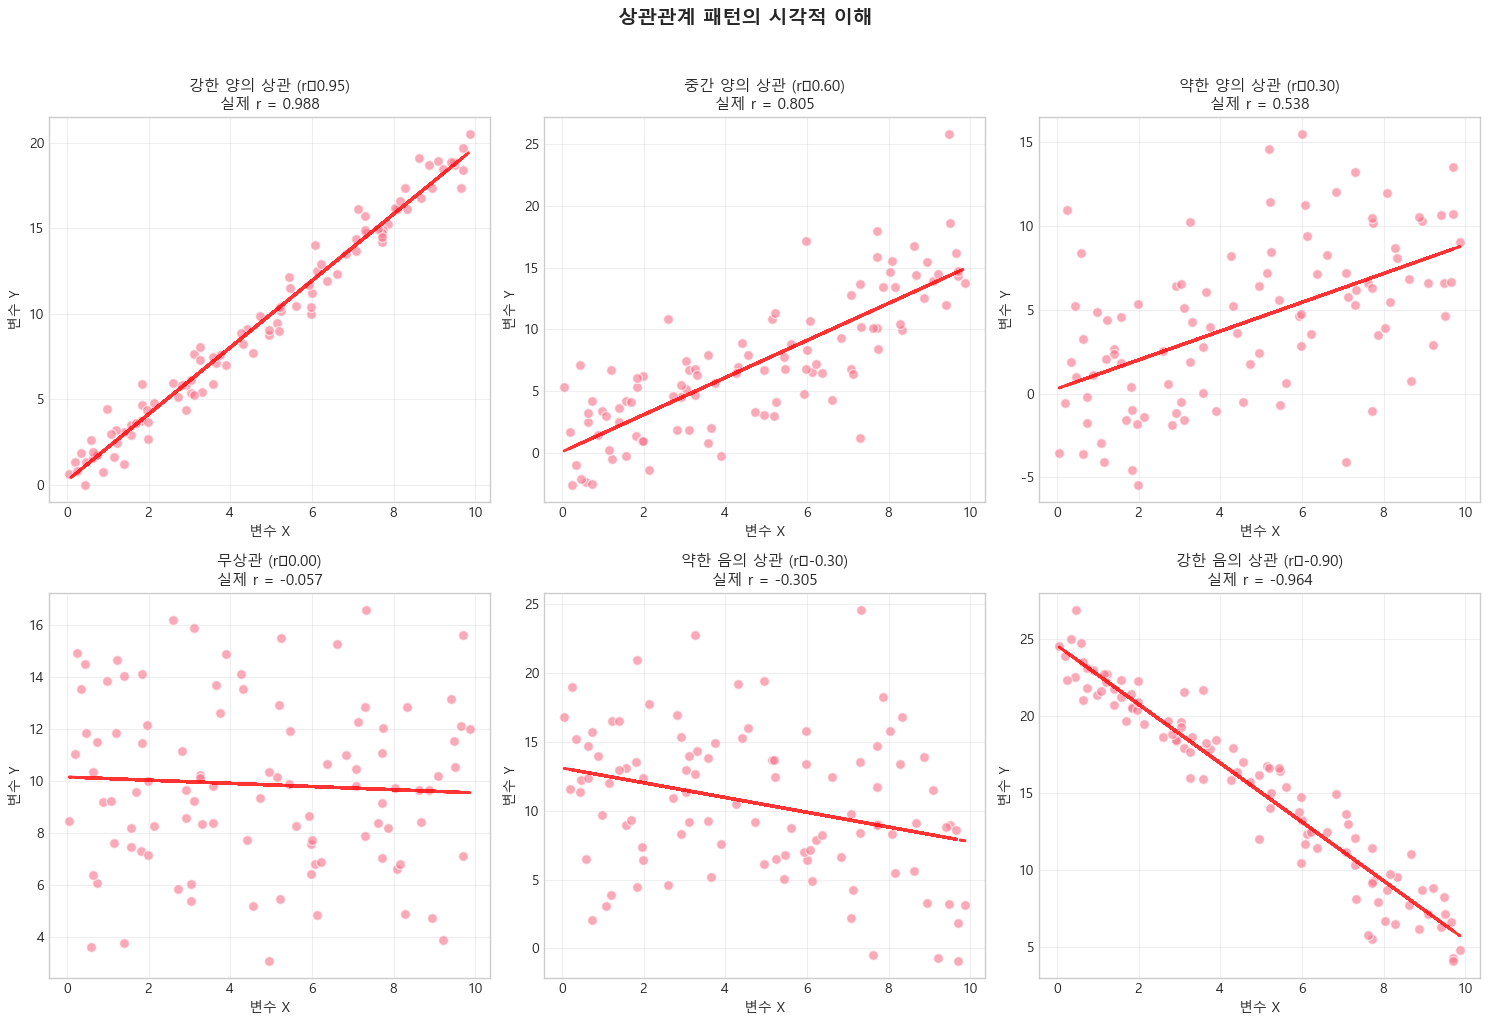

In [6]:
# 다양한 상관관계 패턴 생성
np.random.seed(42)
n = 100

# 기본 X 변수
x = np.random.uniform(0, 10, n)

# 다양한 상관관계 패턴
patterns = {
    '강한 양의 상관 (r≈0.95)': x * 2 + np.random.normal(0, 1, n),
    '중간 양의 상관 (r≈0.60)': x * 1.5 + np.random.normal(0, 3, n),
    '약한 양의 상관 (r≈0.30)': x * 0.8 + np.random.normal(0, 5, n),
    '무상관 (r≈0.00)': np.random.normal(10, 3, n),
    '약한 음의 상관 (r≈-0.30)': -x * 0.8 + 15 + np.random.normal(0, 5, n),
    '강한 음의 상관 (r≈-0.90)': -x * 2 + 25 + np.random.normal(0, 1.5, n)
}

# 6개 패턴 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (title, y) in enumerate(patterns.items()):
    r = np.corrcoef(x, y)[0, 1]
    axes[idx].scatter(x, y, alpha=0.6, edgecolor='white', s=50)
    
    # 추세선 추가
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    axes[idx].plot(x, p(x), 'r--', linewidth=2, alpha=0.8)
    
    axes[idx].set_title(f'{title}\n실제 r = {r:.3f}', fontsize=11)
    axes[idx].set_xlabel('변수 X')
    axes[idx].set_ylabel('변수 Y')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('상관관계 패턴의 시각적 이해', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 시각화 해석 가이드

- **점들이 직선에 가깝게 밀집**할수록 상관관계가 강함
- **우상향 추세**는 양의 상관, **우하향 추세**는 음의 상관을 나타냄
- **점들이 무작위로 분포**하면 상관관계가 없음 (무상관)

---

## ★ 1.3 피어슨 상관계수의 수학적 정의 

### 공분산(Covariance)의 이해

상관계수를 이해하기 위해서는 먼저 **공분산**의 개념을 이해해야 함.

#### 공분산의 정의

두 변수 $X$와 $Y$의 공분산은 각 변수가 평균으로부터 벗어나는 정도가 함께 변하는 경향을 측정함:

$$
\text{Cov}(X, Y) = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})
$$

여기서:
- $X_i, Y_i$: 각 관측값
- $\bar{X}, \bar{Y}$: 각 변수의 평균
- $n$: 표본 크기
- $n-1$: 자유도 보정 (표본 공분산)

#### 공분산의 해석

| 공분산 값 | 의미 |
|----------|------|
| $\text{Cov}(X,Y) > 0$ | X가 평균보다 클 때 Y도 평균보다 큰 경향 (양의 관계) |
| $\text{Cov}(X,Y) < 0$ | X가 평균보다 클 때 Y는 평균보다 작은 경향 (음의 관계) |
| $\text{Cov}(X,Y) \approx 0$ | X와 Y 사이에 선형적 관계 없음 |

#### 공분산의 한계

공분산은 **변수의 단위에 영향**을 받아 해석이 어려움:
- 온도(°C)와 불량률(%): 공분산 = 12.5
- 온도(°F)와 불량률(%): 공분산 = 22.5 (같은 관계인데 값이 다름)

이 문제를 해결하기 위해 **상관계수**를 사용함.

### 피어슨 상관계수 (Pearson Correlation Coefficient)

#### 정의

피어슨 상관계수 $r$은 공분산을 각 변수의 표준편차로 나누어 **표준화**한 값임:

$$
r = \frac{\text{Cov}(X, Y)}{s_X \cdot s_Y} = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2} \cdot \sqrt{\sum_{i=1}^{n} (Y_i - \bar{Y})^2}}
$$

여기서:
- $s_X = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(X_i - \bar{X})^2}$: X의 표본 표준편차
- $s_Y = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(Y_i - \bar{Y})^2}$: Y의 표본 표준편차

#### 상관계수의 특성

1. **범위**: $-1 \leq r \leq 1$
2. **무단위**: 표준화되어 변수의 단위에 영향받지 않음
3. **대칭성**: $r_{XY} = r_{YX}$
4. **선형변환 불변**: $r(aX+b, cY+d) = \text{sign}(ac) \cdot r(X, Y)$

### 상관계수 수기 계산 예시

아래 간단한 데이터로 상관계수를 단계별로 계산함:

| 관측 | 온도(X) | 불량률(Y) |
|------|---------|----------|
| 1 | 20 | 2.0 |
| 2 | 25 | 2.5 |
| 3 | 30 | 3.2 |
| 4 | 35 | 3.8 |
| 5 | 40 | 4.5 |

In [7]:
# 상관계수 수기 계산 과정
X = np.array([20, 25, 30, 35, 40])
Y = np.array([2.0, 2.5, 3.2, 3.8, 4.5])
n = len(X)

# Step 1: 평균 계산
X_mean = np.mean(X)
Y_mean = np.mean(Y)
print(f"Step 1: 평균 계산")
print(f"  X̄ = (20+25+30+35+40)/5 = {X_mean}")
print(f"  Ȳ = (2.0+2.5+3.2+3.8+4.5)/5 = {Y_mean}")
print()

# Step 2: 편차 계산
X_dev = X - X_mean
Y_dev = Y - Y_mean
print(f"Step 2: 편차 계산 (Xi - X̄), (Yi - Ȳ)")
calc_df = pd.DataFrame({
    'X': X,
    'Y': Y,
    'X-X̄': X_dev,
    'Y-Ȳ': Y_dev,
    '(X-X̄)(Y-Ȳ)': X_dev * Y_dev,
    '(X-X̄)²': X_dev**2,
    '(Y-Ȳ)²': Y_dev**2
})
print(calc_df.round(4))
print()

# Step 3: 합계 계산
sum_xy = np.sum(X_dev * Y_dev)
sum_x2 = np.sum(X_dev**2)
sum_y2 = np.sum(Y_dev**2)
print(f"Step 3: 합계 계산")
print(f"  Σ(Xi-X̄)(Yi-Ȳ) = {sum_xy}")
print(f"  Σ(Xi-X̄)² = {sum_x2}")
print(f"  Σ(Yi-Ȳ)² = {sum_y2}")
print()

# Step 4: 상관계수 계산
r = sum_xy / (np.sqrt(sum_x2) * np.sqrt(sum_y2))
print(f"Step 4: 상관계수 계산")
print(f"  r = Σ(Xi-X̄)(Yi-Ȳ) / √[Σ(Xi-X̄)²] × √[Σ(Yi-Ȳ)²]")
print(f"  r = {sum_xy} / (√{sum_x2} × √{sum_y2:.4f})")
print(f"  r = {sum_xy} / ({np.sqrt(sum_x2):.4f} × {np.sqrt(sum_y2):.4f})")
print(f"  r = {r:.6f}")
print()

# 검증: numpy 결과와 비교
r_numpy = np.corrcoef(X, Y)[0, 1]
print(f"검증 (numpy): r = {r_numpy:.6f}")

Step 1: 평균 계산
  X̄ = (20+25+30+35+40)/5 = 30.0
  Ȳ = (2.0+2.5+3.2+3.8+4.5)/5 = 3.2

Step 2: 편차 계산 (Xi - X̄), (Yi - Ȳ)
    X    Y  X-X̄  Y-Ȳ  (X-X̄)(Y-Ȳ)  (X-X̄)²  (Y-Ȳ)²
0  20  2.0 -10.0 -1.2         12.0    100.0    1.44
1  25  2.5  -5.0 -0.7          3.5     25.0    0.49
2  30  3.2   0.0  0.0          0.0      0.0    0.00
3  35  3.8   5.0  0.6          3.0     25.0    0.36
4  40  4.5  10.0  1.3         13.0    100.0    1.69

Step 3: 합계 계산
  Σ(Xi-X̄)(Yi-Ȳ) = 31.5
  Σ(Xi-X̄)² = 250.0
  Σ(Yi-Ȳ)² = 3.9799999999999995

Step 4: 상관계수 계산
  r = Σ(Xi-X̄)(Yi-Ȳ) / √[Σ(Xi-X̄)²] × √[Σ(Yi-Ȳ)²]
  r = 31.5 / (√250.0 × √3.9800)
  r = 31.5 / (15.8114 × 1.9950)
  r = 0.998617

검증 (numpy): r = 0.998617


---

## 1.4 상관계수의 해석 기준

### |r| 값에 따른 해석 가이드라인

| r 범위 | 강도 | 실무적 의미 |
|----------|------|----------|
| 0.00 ~ 0.10 | 무시할 수 있는 상관 | 실질적 관계 없음 |
| 0.10 ~ 0.30 | 약한 상관 | 관계가 미미함, 추가 조사 필요 |
| 0.30 ~ 0.50 | 중간 상관 | 어느 정도 관계 있음 |
| 0.50 ~ 0.70 | 강한 상관 | 명확한 관계, 실무 활용 가능 |
| 0.70 ~ 0.90 | 매우 강한 상관 | 밀접한 관계, 예측에 유용 |
| 0.90 ~ 1.00 | 거의 완벽한 상관 | 매우 밀접, 함수 관계에 가까움 |

> **주의**: 이 기준은 분야에 따라 다를 수 있음. 사회과학에서는 r=0.3도 의미 있지만, 자연과학이나 공학에서는 r=0.7 이상을 요구하는 경우가 많음.

In [8]:
# 상관계수 해석 함수
def interpret_correlation(r):
    """
    상관계수를 해석하는 함수
    
    Parameters:
    -----------
    r : float
        피어슨 상관계수 값 (-1 ~ 1)
    
    Returns:
    --------
    str : 상관관계 해석 문자열
    """
    abs_r = abs(r)
    
    # 방향 결정
    if r > 0:
        direction = "양의"
    elif r < 0:
        direction = "음의"
    else:
        return "상관관계 없음 (r = 0)"
    
    # 강도 결정
    if abs_r >= 0.9:
        strength = "거의 완벽한"
    elif abs_r >= 0.7:
        strength = "매우 강한"
    elif abs_r >= 0.5:
        strength = "강한"
    elif abs_r >= 0.3:
        strength = "중간"
    elif abs_r >= 0.1:
        strength = "약한"
    else:
        strength = "무시할 수 있는"
    
    return f"{strength} {direction} 상관관계 (r = {r:.4f})"

# 테스트
test_values = [0.95, 0.75, 0.50, 0.25, 0.05, -0.45, -0.85]
print("상관계수 해석 예시:")
print("-" * 50)
for r in test_values:
    print(f"  r = {r:+.2f}: {interpret_correlation(r)}")

상관계수 해석 예시:
--------------------------------------------------
  r = +0.95: 거의 완벽한 양의 상관관계 (r = 0.9500)
  r = +0.75: 매우 강한 양의 상관관계 (r = 0.7500)
  r = +0.50: 강한 양의 상관관계 (r = 0.5000)
  r = +0.25: 약한 양의 상관관계 (r = 0.2500)
  r = +0.05: 무시할 수 있는 양의 상관관계 (r = 0.0500)
  r = -0.45: 중간 음의 상관관계 (r = -0.4500)
  r = -0.85: 매우 강한 음의 상관관계 (r = -0.8500)


---

## 1.5 상관계수의 통계적 검정

### 가설 검정

표본에서 계산된 상관계수가 **우연에 의한 것인지, 모집단에서도 실제로 상관관계가 있는지** 확인하기 위해 통계적 검정을 수행함.

#### 가설 설정

- **귀무가설 ($H_0$)**: $\rho = 0$ (모집단에서 상관관계 없음)
- **대립가설 ($H_1$)**: $\rho \neq 0$ (모집단에서 상관관계 있음)

여기서 $\rho$(로)는 모집단 상관계수임.

#### 검정 통계량 (t-test)

$$
t = \frac{r\sqrt{n-2}}{\sqrt{1-r^2}}
$$

이 통계량은 자유도 $df = n-2$인 t-분포를 따름.

#### p-value 해석

- **p < 0.05**: 통계적으로 유의함 (귀무가설 기각)
- **p < 0.01**: 매우 유의함
- **p < 0.001**: 고도로 유의함

In [9]:
# 상관계수 검정 예시
np.random.seed(42)

# 샘플 데이터 생성
n = 30
x = np.random.uniform(60, 100, n)  # 온도
y = 0.08 * x + np.random.normal(0, 0.8, n)  # 불량률 (양의 상관)

# scipy를 이용한 상관계수 및 p-value 계산
r, p_value = stats.pearsonr(x, y)

# t-통계량 직접 계산
t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
df = n - 2

print("상관계수 통계적 검정 결과")
print("=" * 50)
print(f"표본 크기 (n): {n}")
print(f"상관계수 (r): {r:.4f}")
print(f"t-통계량: {t_stat:.4f}")
print(f"자유도 (df): {df}")
print(f"p-value: {p_value:.6f}")
print()

# 유의성 판정
alpha = 0.05
if p_value < alpha:
    print(f"결론: p-value({p_value:.4f}) < α({alpha})이므로")
    print(f"       귀무가설을 기각함.")
    print(f"       두 변수 간에 통계적으로 유의한 상관관계가 있음.")
else:
    print(f"결론: p-value({p_value:.4f}) >= α({alpha})이므로")
    print(f"       귀무가설을 기각할 수 없음.")
    print(f"       두 변수 간 상관관계가 통계적으로 유의하지 않음.")

상관계수 통계적 검정 결과
표본 크기 (n): 30
상관계수 (r): 0.6620
t-통계량: 4.6735
자유도 (df): 28
p-value: 0.000068

결론: p-value(0.0001) < α(0.05)이므로
       귀무가설을 기각함.
       두 변수 간에 통계적으로 유의한 상관관계가 있음.


---

## 1.6 상관행렬 (Correlation Matrix)

### 정의

여러 변수 간의 상관관계를 한눈에 파악하기 위해 **상관행렬**을 사용함. $p$개의 변수가 있을 때, 상관행렬 $R$은 $p \times p$ 대칭 행렬임:

$$
R = \begin{pmatrix}
1 & r_{12} & r_{13} & \cdots & r_{1p} \\
r_{21} & 1 & r_{23} & \cdots & r_{2p} \\
r_{31} & r_{32} & 1 & \cdots & r_{3p} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
r_{p1} & r_{p2} & r_{p3} & \cdots & 1
\end{pmatrix}
$$

### 특성

- 대각선 원소는 항상 1 (자기 자신과의 상관)
- 대칭 행렬: $r_{ij} = r_{ji}$
- 양정치(positive semi-definite) 행렬

In [10]:
# 다변량 제조 데이터 생성
np.random.seed(123)
n = 100

# 기본 변수
temperature = np.random.uniform(60, 100, n)  # 온도
humidity = np.random.uniform(30, 70, n)  # 습도
pressure = np.random.uniform(1.0, 2.0, n)  # 압력

# 종속 변수들 (관계성 부여)
defect_rate = 0.05 * temperature + 0.02 * humidity + np.random.normal(0, 0.8, n)
production = 500 - 3 * temperature + 2 * pressure * 10 + np.random.normal(0, 20, n)
energy = 0.8 * temperature + 0.3 * pressure * 100 + np.random.normal(0, 5, n)

# DataFrame 생성
mfg_df = pd.DataFrame({
    '온도': temperature,
    '습도': humidity,
    '압력': pressure,
    '불량률': defect_rate,
    '생산량': production,
    '에너지사용량': energy
})

# 상관행렬 계산
corr_matrix = mfg_df.corr()

print("상관행렬:")
print(corr_matrix.round(3))

상관행렬:
           온도     습도     압력    불량률    생산량  에너지사용량
온도      1.000 -0.093 -0.010  0.529 -0.850   0.637
습도     -0.093  1.000  0.095  0.258  0.179   0.044
압력     -0.010  0.095  1.000 -0.039  0.159   0.663
불량률     0.529  0.258 -0.039  1.000 -0.362   0.338
생산량    -0.850  0.179  0.159 -0.362  1.000  -0.425
에너지사용량  0.637  0.044  0.663  0.338 -0.425   1.000


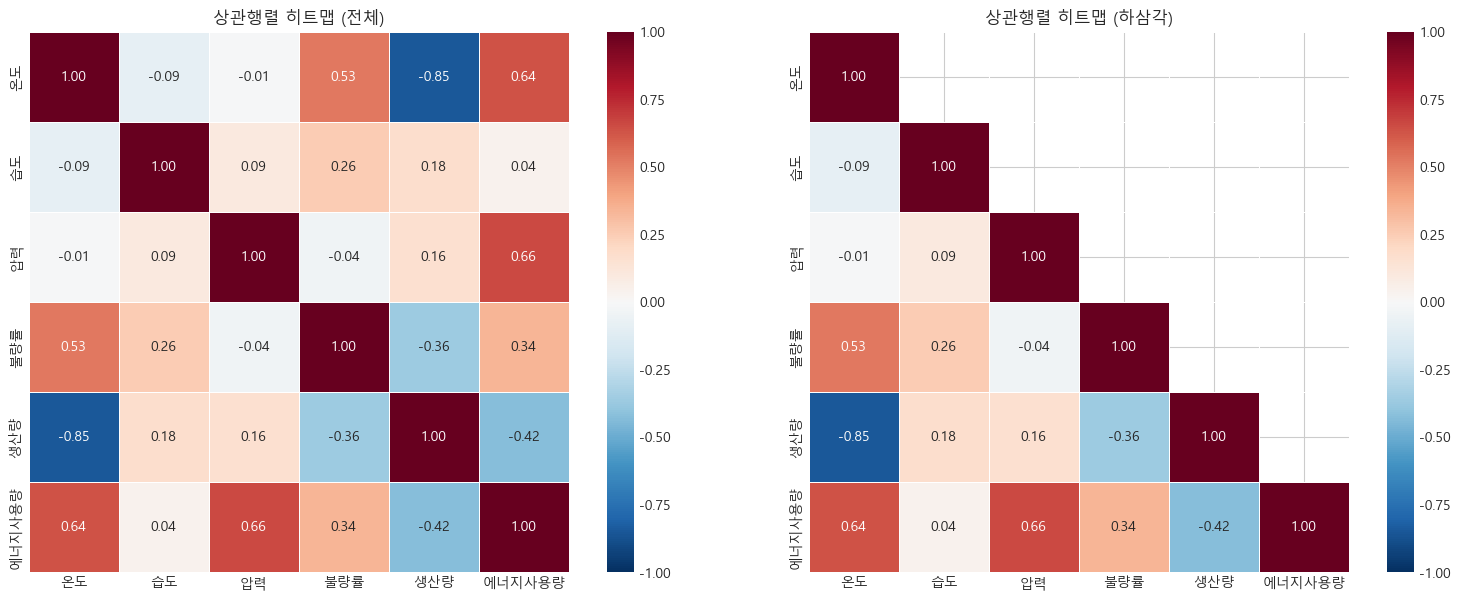


주요 상관관계 (|r| >= 0.5):
--------------------------------------------------
  온도 ↔ 불량률: r = 0.529
  온도 ↔ 생산량: r = -0.850
  온도 ↔ 에너지사용량: r = 0.637
  압력 ↔ 에너지사용량: r = 0.663


In [11]:
# 상관행렬 히트맵 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 기본 히트맵
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # 상삼각 마스크
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            ax=axes[0])
axes[0].set_title('상관행렬 히트맵 (전체)', fontsize=12)

# 하삼각 히트맵 (중복 제거)
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            ax=axes[1])
axes[1].set_title('상관행렬 히트맵 (하삼각)', fontsize=12)

plt.tight_layout()
plt.show()

# 주요 상관관계 추출
print("\n주요 상관관계 (|r| >= 0.5):")
print("-" * 50)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.5:
            var1 = corr_matrix.columns[i]
            var2 = corr_matrix.columns[j]
            print(f"  {var1} ↔ {var2}: r = {r:.3f}")

---

## 1.7 상관관계와 인과관계

### 핵심 원칙: ★ Correlation ≠ Causation ★

> **"상관관계가 있다고 해서 인과관계가 있는 것은 아니다."**

### 허위 상관 (Spurious Correlation)의 예시

| 변수 A | 변수 B | 상관계수 | 실제 관계 |
|--------|--------|----------|----------|
| 아이스크림 판매량 | 익사 사고 수 | r ≈ 0.85 | 숨겨진 변수: 기온 |
| 니콜라스 케이지 출연작 수 | 수영장 익사자 수 | r ≈ 0.67 | 우연의 일치 |
| 해적 수 감소 | 지구 온도 상승 | r ≈ -0.95 | 완전한 우연 |

### 인과관계 추론을 위한 조건 (Hill's Criteria 요약)

1. **시간적 선후관계**: 원인이 결과보다 먼저 발생해야 함
2. **강도(Strength)**: 강한 상관관계일수록 인과관계 가능성 높음
3. **일관성(Consistency)**: 다른 연구/상황에서도 재현됨
4. **기전(Mechanism)**: 합리적인 메커니즘이 존재함
5. **실험적 증거**: 통제된 실험에서 확인됨

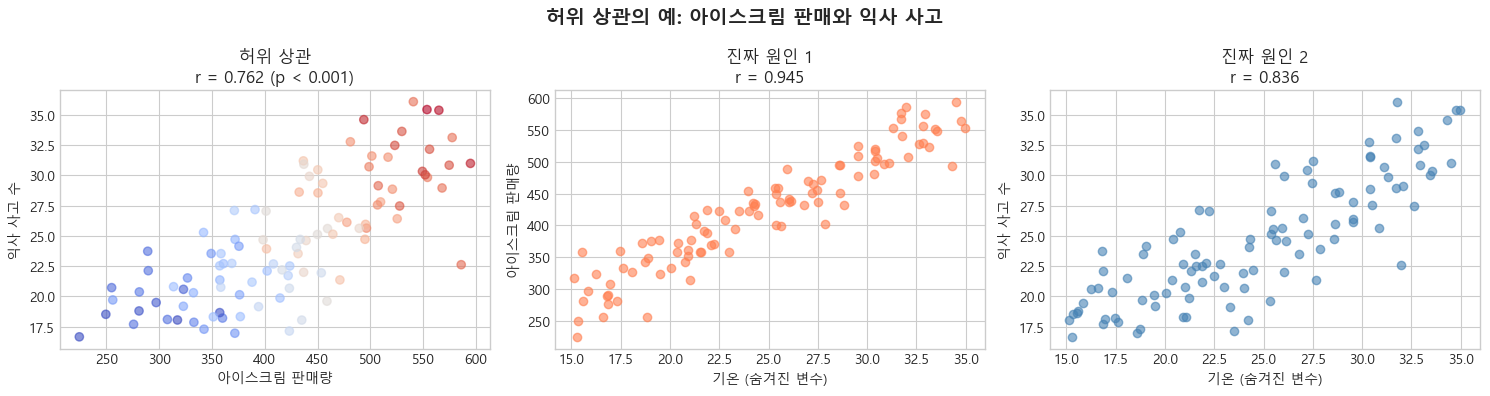


결론:
  아이스크림 판매량과 익사 사고 수: r = 0.762 (허위 상관)
  기온과 아이스크림 판매량: r = 0.945 (진짜 원인)
  기온과 익사 사고 수: r = 0.836 (진짜 원인)

  → 아이스크림을 많이 팔면 익사 사고가 늘어나는 것이 아니라,
    기온이 높을 때 둘 다 증가하는 것임 (제3의 변수 효과).


In [12]:
# 허위 상관 시뮬레이션: 숨겨진 변수 효과
np.random.seed(777)
n = 100

# 숨겨진 변수: 기온
hidden_temperature = np.random.uniform(15, 35, n)

# 관측 변수들 (둘 다 기온에 의해 영향받음)
ice_cream_sales = 50 + 15 * hidden_temperature + np.random.normal(0, 30, n)
drowning_incidents = 5 + 0.8 * hidden_temperature + np.random.normal(0, 3, n)

# 상관관계 계산
r_spurious, p_spurious = stats.pearsonr(ice_cream_sales, drowning_incidents)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 허위 상관
axes[0].scatter(ice_cream_sales, drowning_incidents, alpha=0.6, c=hidden_temperature, cmap='coolwarm')
axes[0].set_xlabel('아이스크림 판매량')
axes[0].set_ylabel('익사 사고 수')
axes[0].set_title(f'허위 상관\nr = {r_spurious:.3f} (p < 0.001)')

# 실제 원인: 기온 → 아이스크림
r1, _ = stats.pearsonr(hidden_temperature, ice_cream_sales)
axes[1].scatter(hidden_temperature, ice_cream_sales, alpha=0.6, color='coral')
axes[1].set_xlabel('기온 (숨겨진 변수)')
axes[1].set_ylabel('아이스크림 판매량')
axes[1].set_title(f'진짜 원인 1\nr = {r1:.3f}')

# 실제 원인: 기온 → 익사
r2, _ = stats.pearsonr(hidden_temperature, drowning_incidents)
axes[2].scatter(hidden_temperature, drowning_incidents, alpha=0.6, color='steelblue')
axes[2].set_xlabel('기온 (숨겨진 변수)')
axes[2].set_ylabel('익사 사고 수')
axes[2].set_title(f'진짜 원인 2\nr = {r2:.3f}')

plt.suptitle('허위 상관의 예: 아이스크림 판매와 익사 사고', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n결론:")
print(f"  아이스크림 판매량과 익사 사고 수: r = {r_spurious:.3f} (허위 상관)")
print(f"  기온과 아이스크림 판매량: r = {r1:.3f} (진짜 원인)")
print(f"  기온과 익사 사고 수: r = {r2:.3f} (진짜 원인)")
print("\n  → 아이스크림을 많이 팔면 익사 사고가 늘어나는 것이 아니라,")
print("    기온이 높을 때 둘 다 증가하는 것임 (제3의 변수 효과).")

### 제조업에서의 교훈

**잘못된 결론 예시:**
- "가동 시간이 길면 불량률이 높다" → 가동 시간을 줄이자?
- 실제 원인: 장시간 가동 시 작업자 피로 증가, 설비 과열 등

**올바른 접근:**
1. 상관관계 확인 후 **도메인 전문가**와 논의
2. 가능한 **제3의 변수(교란 변수)** 탐색
3. 통제된 **실험(A/B 테스트)** 수행
4. 시간에 따른 **인과 순서** 확인

---

# 2. 단순선형회귀의 수학적 원리

---

## 2.1 회귀분석의 개념

### 정의

**회귀분석(Regression Analysis)** 은 하나 이상의 **독립변수(X)** 가 **종속변수(Y)** 에 미치는 영향을 분석하고, 그 관계를 **수학적 함수**로 표현하는 통계적 방법임. 

> -> 즉, 통계적 방법을 쓰던, AI를 이용하던 회귀처리의 핵심은 이미 주어진 독립변수의 관측이 있고, 그 관측을 기반으로 수학적 함수를 추론해내고 모델링하는것

### 용어 정리

| 용어 | 다른 표현 | 의미 | 예시 |
|------|----------|------|------|
| **독립변수 (X)** | 설명변수, 예측변수, Feature | 원인, 입력, 예측에 사용 | 온도, 습도, 압력 |
| **종속변수 (Y)** | 반응변수, 목표변수, Target | 결과, 출력, 예측 대상 | 불량률, 생산량 |

### 회귀(Regression)라는 용어의 유래

영국의 유전학자 Francis Galton이 1886년 부모와 자녀의 키 관계를 연구하면서 처음 사용함:
- 키가 큰 부모의 자녀는 부모보다 작은 경향
- 키가 작은 부모의 자녀는 부모보다 큰 경향
- "평균으로 회귀(regression to the mean)"하는 현상을 발견

## 2.2 단순선형회귀 모델

### 모델 정의

단순선형회귀는 **하나의 독립변수**로 종속변수를 예측하는 가장 기본적인 회귀 모델임:

$$
Y = \beta_0 + \beta_1 X + \varepsilon
$$

여기서:
- $Y$: 종속변수 (예측 대상)
- $X$: 독립변수 (입력)
- $\beta_0$: **절편(intercept)** - $X=0$일 때 $Y$의 기대값
- $\beta_1$: **기울기(slope)** - $X$가 1단위 증가할 때 $Y$의 변화량
- $\varepsilon$: **오차항(error term)** - 모델이 설명하지 못하는 변동

> 여기에서, 나중에 AI로 이행 시 Y는 타겟, X는 인풋, 절편은 그대로, 기울기는 weight로 용어가 변함에 유의할 것

### 모수와 통계량

| 구분 | 모수(Parameter) | 추정량(Estimator) |
|------|----------------|------------------|
| 절편 | $\beta_0$ | $\hat{\beta}_0$ 또는 $b_0$ |
| 기울기 | $\beta_1$ | $\hat{\beta}_1$ 또는 $b_1$ |
| 예측값 | $E[Y|X]$ | $\hat{Y}$ |

### 예측식

추정된 회귀식을 사용한 예측:

$$
\hat{Y} = \hat{\beta}_0 + \hat{\beta}_1 X
$$

## 2.3 최소제곱법 (Ordinary Least Squares, OLS)

### 목표

실제 관측값 $y_i$와 예측값 $\hat{y}_i$ 사이의 차이(잔차)의 **제곱합을 최소화**하는 $\beta_0$, $\beta_1$을 찾는 것:

$$
\min_{\beta_0, \beta_1} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 = \min_{\beta_0, \beta_1} \sum_{i=1}^{n} (y_i - \beta_0 - \beta_1 x_i)^2
$$

### 왜 "제곱"인가?

1. **부호 상쇄 방지**: 양의 오차와 음의 오차가 상쇄되는 것을 방지
2. **큰 오차에 페널티**: 오차가 클수록 더 큰 페널티 부여
3. **수학적 편의**: 미분이 용이하여 해석적 해(closed-form solution) 도출 가능

### 정규방정식 (Normal Equations)

비용함수를 $\beta_0$, $\beta_1$에 대해 편미분하고 0으로 설정:

$$
\frac{\partial}{\partial \beta_0} \sum (y_i - \beta_0 - \beta_1 x_i)^2 = 0
$$

$$
\frac{\partial}{\partial \beta_1} \sum (y_i - \beta_0 - \beta_1 x_i)^2 = 0
$$

### OLS 추정량

정규방정식을 풀면:

$$
\hat{\beta}_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2} = \frac{S_{xy}}{S_{xx}}
$$

$$
\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}
$$

여기서:
- $S_{xy} = \sum(x_i - \bar{x})(y_i - \bar{y})$: X와 Y의 교차곱 합
- $S_{xx} = \sum(x_i - \bar{x})^2$: X의 편차제곱합

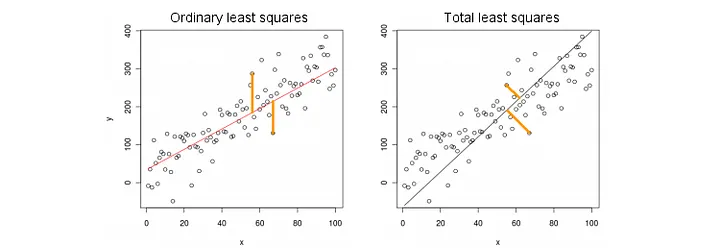!

In [13]:
# OLS 수기 계산 vs sklearn 비교

# 데이터
X = np.array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65])
Y = np.array([2.1, 2.4, 3.0, 3.5, 4.2, 4.6, 5.1, 5.5, 6.0, 6.4])
n = len(X)

print("=" * 60)
print("OLS 추정량 수기 계산")
print("=" * 60)

# Step 1: 평균 계산
x_bar = np.mean(X)
y_bar = np.mean(Y)
print(f"\n[Step 1] 평균 계산")
print(f"  x̄ = {x_bar}")
print(f"  ȳ = {y_bar}")

# Step 2: 편차 및 교차곱 계산
x_dev = X - x_bar
y_dev = Y - y_bar
Sxy = np.sum(x_dev * y_dev)
Sxx = np.sum(x_dev ** 2)
print(f"\n[Step 2] 편차 및 교차곱")
print(f"  Sxy = Σ(xi - x̄)(yi - ȳ) = {Sxy}")
print(f"  Sxx = Σ(xi - x̄)² = {Sxx}")

# Step 3: 기울기 계산
beta1_manual = Sxy / Sxx
print(f"\n[Step 3] 기울기 β₁ 계산")
print(f"  β̂₁ = Sxy / Sxx = {Sxy} / {Sxx} = {beta1_manual:.6f}")

# Step 4: 절편 계산
beta0_manual = y_bar - beta1_manual * x_bar
print(f"\n[Step 4] 절편 β₀ 계산")
print(f"  β̂₀ = ȳ - β̂₁ × x̄ = {y_bar} - {beta1_manual:.6f} × {x_bar} = {beta0_manual:.6f}")

print(f"\n[결과] 회귀식")
print(f"  Ŷ = {beta0_manual:.4f} + {beta1_manual:.4f} × X")

# sklearn으로 검증
print("\n" + "=" * 60)
print("sklearn LinearRegression 검증")
print("=" * 60)

from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X.reshape(-1, 1), Y)

print(f"  β̂₀ (절편): {model.intercept_:.6f}")
print(f"  β̂₁ (기울기): {model.coef_[0]:.6f}")
print(f"\n→ 수기 계산과 sklearn 결과가 일치함을 확인")

OLS 추정량 수기 계산

[Step 1] 평균 계산
  x̄ = 42.5
  ȳ = 4.279999999999999

[Step 2] 편차 및 교차곱
  Sxy = Σ(xi - x̄)(yi - ȳ) = 204.0
  Sxx = Σ(xi - x̄)² = 2062.5

[Step 3] 기울기 β₁ 계산
  β̂₁ = Sxy / Sxx = 204.0 / 2062.5 = 0.098909

[Step 4] 절편 β₀ 계산
  β̂₀ = ȳ - β̂₁ × x̄ = 4.279999999999999 - 0.098909 × 42.5 = 0.076364

[결과] 회귀식
  Ŷ = 0.0764 + 0.0989 × X

sklearn LinearRegression 검증
  β̂₀ (절편): 0.076364
  β̂₁ (기울기): 0.098909

→ 수기 계산과 sklearn 결과가 일치함을 확인


## 간단한 회귀 수행

In [85]:
# =============================================================================
# Step 1. 데이터 준비
# =============================================================================
# X: 독립변수 (2차원 배열 필수)
# y: 종속변수 (1차원 배열)
X = df[['가동업체']].values          # 또는 df['가동업체'].values.reshape(-1, 1)
y = df['고용(계)'].values

In [86]:
# =============================================================================
# Step 2. 데이터 분할
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 테스트 데이터 비율 (20%)
    random_state=42     # 재현성을 위한 시드값
)

In [87]:
# =============================================================================
# Step 3. 모델 생성 및 학습
# =============================================================================
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [89]:
#하나 볼 것!. fit에 들어가는 데이터의 유형
X_train

array([[  7],
       [ 13],
       [938],
       ...,
       [ 48],
       [  0],
       [  0]], shape=(1141, 1))

In [90]:
# =============================================================================
# Step 4. 예측
# =============================================================================
y_pred = model.predict(X_test)

In [91]:
# =============================================================================
# Step 5. 평가
# =============================================================================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

In [92]:
# 절편 (β₀)
print(f"절편: {model.intercept_:.4f}")

# 기울기 (β₁)
print(f"기울기: {model.coef_[0]:.4f}")

# 회귀식
print(f"y = {model.intercept_:.2f} + {model.coef_[0]:.4f} × X")

절편: 756.7884
기울기: 11.0003
y = 756.79 + 11.0003 × X


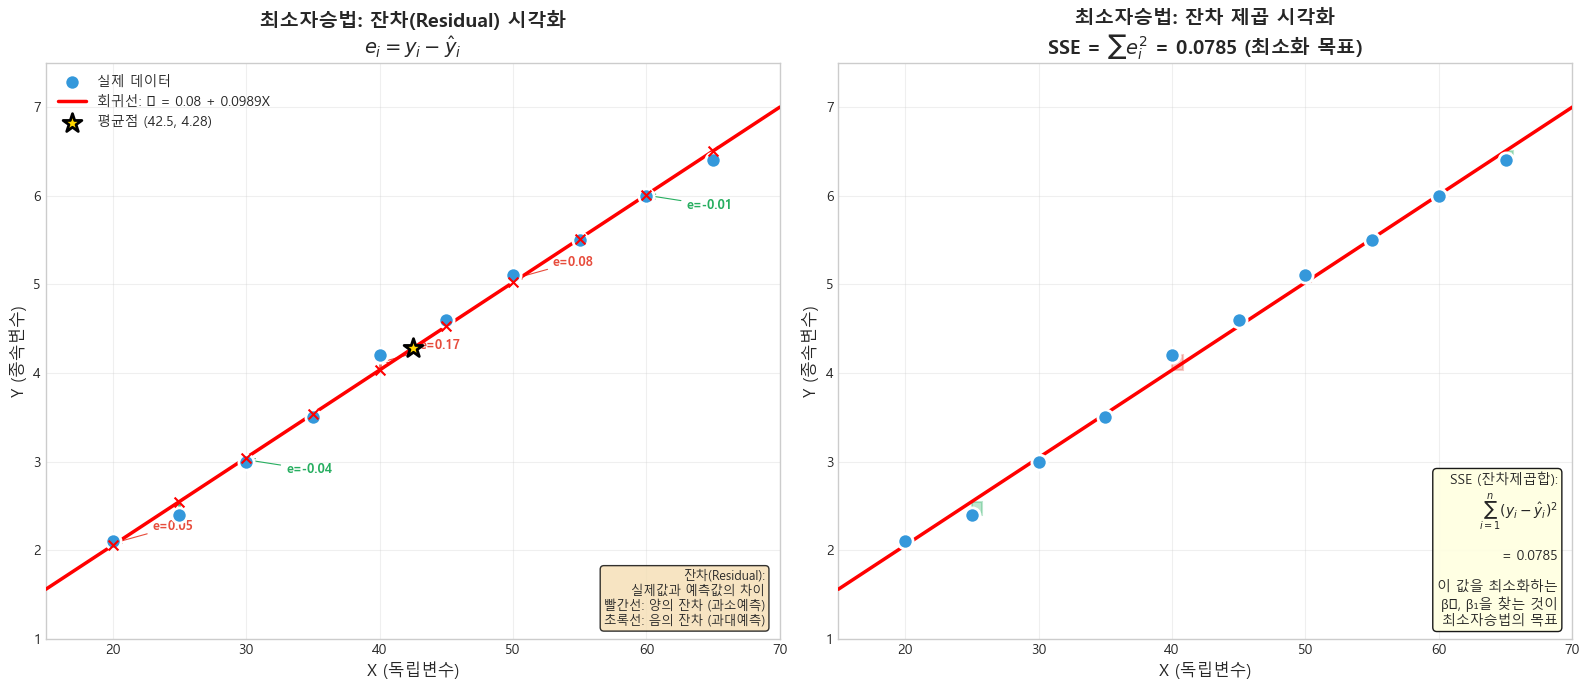

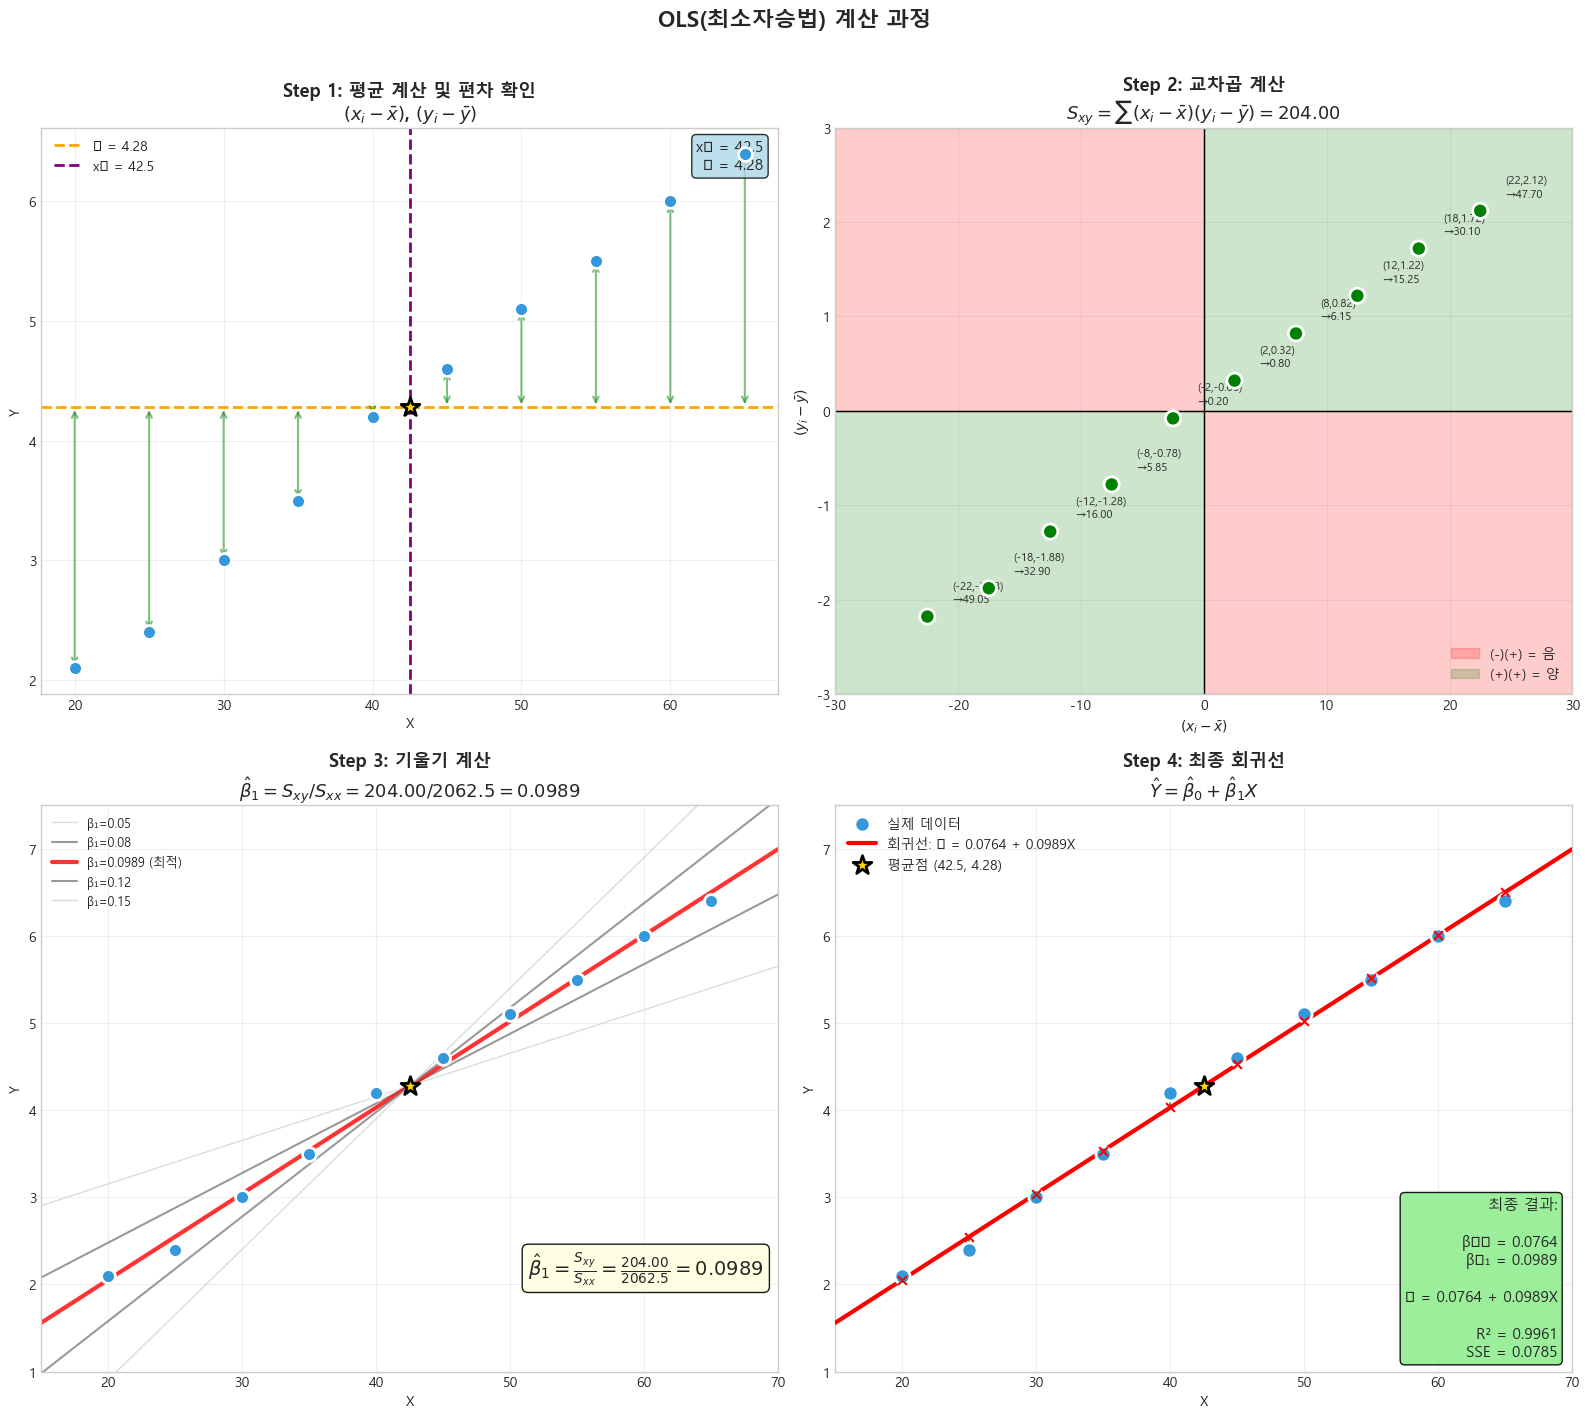

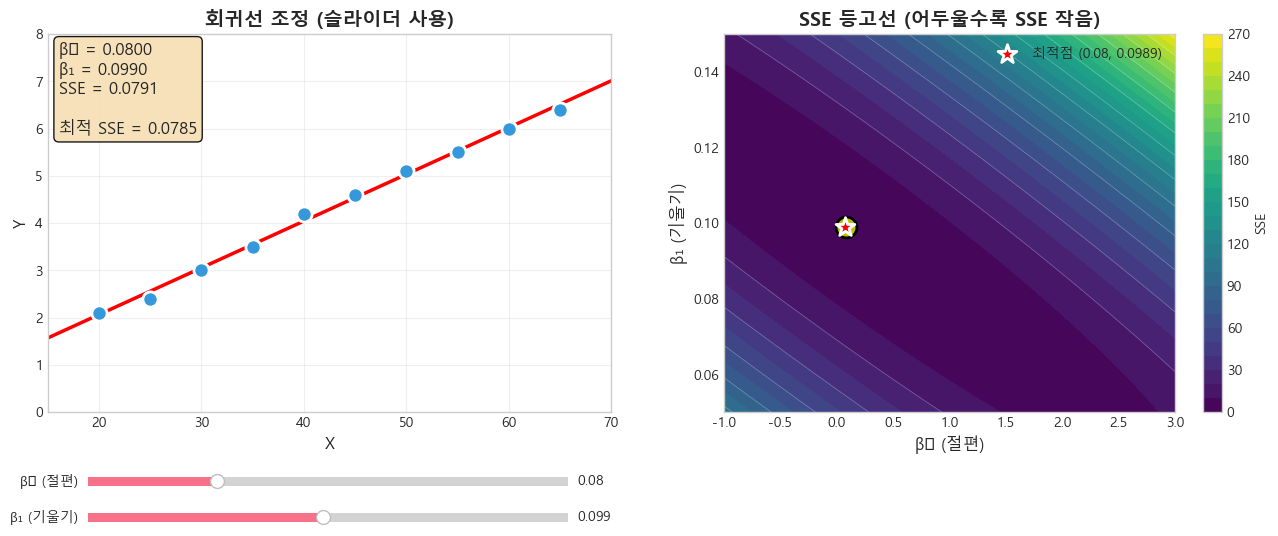

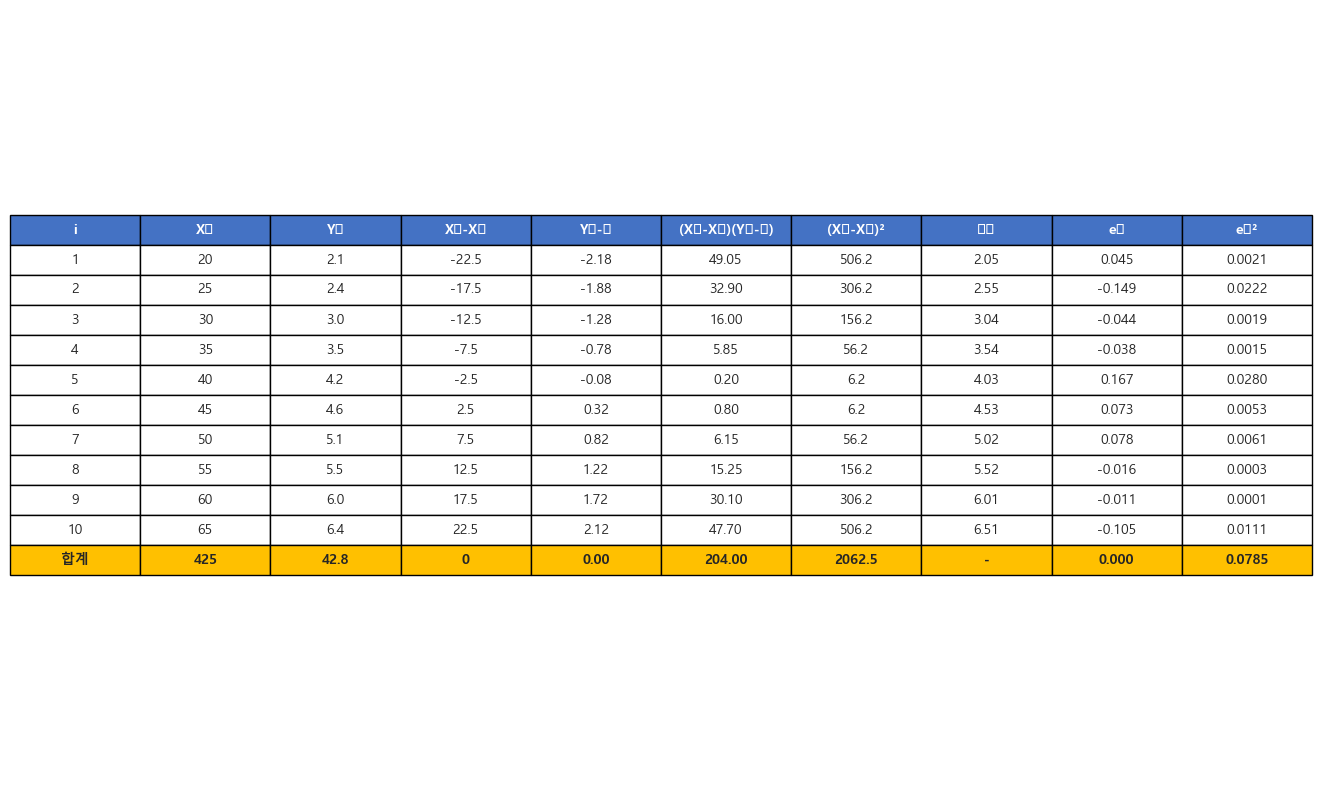

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.widgets import Slider
import matplotlib.patches as mpatches

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
plt.rcParams['axes.unicode_minus'] = False

# =============================================================================
# 데이터 준비
# =============================================================================
X = np.array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65])
Y = np.array([2.1, 2.4, 3.0, 3.5, 4.2, 4.6, 5.1, 5.5, 6.0, 6.4])
n = len(X)

# OLS 계산
x_bar, y_bar = np.mean(X), np.mean(Y)
Sxy = np.sum((X - x_bar) * (Y - y_bar))
Sxx = np.sum((X - x_bar) ** 2)
beta1 = Sxy / Sxx
beta0 = y_bar - beta1 * x_bar
Y_pred = beta0 + beta1 * X
residuals = Y - Y_pred
SSE = np.sum(residuals ** 2)

# =============================================================================
# 그림 1: 최소자승법 개념 - 잔차와 잔차 제곱 시각화
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- 왼쪽: 잔차(수직 거리) 시각화 ---
ax1 = axes[0]
ax1.scatter(X, Y, s=120, c='#3498db', edgecolor='white', linewidth=2, zorder=5, label='실제 데이터')

# 회귀선
X_line = np.linspace(15, 70, 100)
Y_line = beta0 + beta1 * X_line
ax1.plot(X_line, Y_line, 'r-', linewidth=2.5, label=f'회귀선: Ŷ = {beta0:.2f} + {beta1:.4f}X', zorder=4)

# 잔차 표시 (수직선)
for i, (xi, yi, yi_pred, ei) in enumerate(zip(X, Y, Y_pred, residuals)):
    color = '#e74c3c' if ei > 0 else '#27ae60'
    ax1.plot([xi, xi], [yi_pred, yi], color=color, linewidth=2, linestyle='--', alpha=0.8, zorder=3)
    ax1.scatter(xi, yi_pred, color='red', s=50, marker='x', zorder=6)
    
    # 잔차 값 어노테이션 (일부만)
    if i % 2 == 0:
        offset = 0.15 if ei > 0 else -0.15
        ax1.annotate(f'e={ei:.2f}', xy=(xi, (yi + yi_pred)/2), 
                    xytext=(xi + 3, (yi + yi_pred)/2 + offset),
                    fontsize=9, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

# 평균점 표시
ax1.scatter(x_bar, y_bar, s=200, c='gold', edgecolor='black', linewidth=2, 
           marker='*', zorder=7, label=f'평균점 ({x_bar}, {y_bar:.2f})')

ax1.set_xlabel('X (독립변수)', fontsize=12)
ax1.set_ylabel('Y (종속변수)', fontsize=12)
ax1.set_title('최소자승법: 잔차(Residual) 시각화\n$e_i = y_i - \\hat{y}_i$', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(15, 70)
ax1.set_ylim(1, 7.5)

# 텍스트 박스: 잔차 설명
textstr = '잔차(Residual):\n실제값과 예측값의 차이\n빨간선: 양의 잔차 (과소예측)\n초록선: 음의 잔차 (과대예측)'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax1.text(0.98, 0.02, textstr, transform=ax1.transAxes, fontsize=9,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

# --- 오른쪽: 잔차 제곱 시각화 ---
ax2 = axes[1]
ax2.scatter(X, Y, s=120, c='#3498db', edgecolor='white', linewidth=2, zorder=5)
ax2.plot(X_line, Y_line, 'r-', linewidth=2.5, zorder=4)

# 잔차 제곱을 정사각형으로 표시
for xi, yi, yi_pred, ei in zip(X, Y, Y_pred, residuals):
    # 정사각형 크기 = |잔차|
    size = abs(ei)
    # 잔차 제곱 시각화 (정사각형)
    if ei > 0:
        rect = Rectangle((xi, yi_pred), size * 5, ei, 
                         linewidth=1.5, edgecolor='#e74c3c', facecolor='#e74c3c', alpha=0.3)
    else:
        rect = Rectangle((xi, yi), size * 5, -ei,
                         linewidth=1.5, edgecolor='#27ae60', facecolor='#27ae60', alpha=0.3)
    ax2.add_patch(rect)

ax2.set_xlabel('X (독립변수)', fontsize=12)
ax2.set_ylabel('Y (종속변수)', fontsize=12)
ax2.set_title(f'최소자승법: 잔차 제곱 시각화\nSSE = $\\sum e_i^2$ = {SSE:.4f} (최소화 목표)', 
             fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(15, 70)
ax2.set_ylim(1, 7.5)

# 텍스트 박스: SSE 설명
textstr2 = f'SSE (잔차제곱합):\n$\\sum_{{i=1}}^{{n}}(y_i - \\hat{{y}}_i)^2$\n\n= {SSE:.4f}\n\n이 값을 최소화하는\nβ₀, β₁을 찾는 것이\n최소자승법의 목표'
props2 = dict(boxstyle='round', facecolor='lightyellow', alpha=0.9)
ax2.text(0.98, 0.02, textstr2, transform=ax2.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right', bbox=props2)

plt.tight_layout()
plt.show()

# =============================================================================
# 그림 2: OLS 계산 과정 단계별 시각화
# =============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# --- (1) 평균점과 편차 ---
ax = axes[0, 0]
ax.scatter(X, Y, s=100, c='#3498db', edgecolor='white', linewidth=2, zorder=5)
ax.axhline(y=y_bar, color='orange', linestyle='--', linewidth=2, label=f'ȳ = {y_bar:.2f}')
ax.axvline(x=x_bar, color='purple', linestyle='--', linewidth=2, label=f'x̄ = {x_bar:.1f}')
ax.scatter(x_bar, y_bar, s=200, c='gold', edgecolor='black', linewidth=2, marker='*', zorder=7)

# 편차 화살표
for xi, yi in zip(X, Y):
    ax.annotate('', xy=(xi, y_bar), xytext=(xi, yi),
               arrowprops=dict(arrowstyle='<->', color='green', lw=1.5, alpha=0.5))

ax.set_title('Step 1: 평균 계산 및 편차 확인\n$(x_i - \\bar{x})$, $(y_i - \\bar{y})$', fontsize=13, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

# 계산 결과 표시
calc_text = f'x̄ = {x_bar}\nȳ = {y_bar:.2f}'
ax.text(0.98, 0.98, calc_text, transform=ax.transAxes, fontsize=11,
       verticalalignment='top', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# --- (2) 교차곱 시각화 ---
ax = axes[0, 1]

# 4사분면 표시
ax.axhline(y=0, color='black', linewidth=1)
ax.axvline(x=0, color='black', linewidth=1)
ax.fill_between([-30, 0], [0, 0], [3, 3], alpha=0.2, color='red', label='(-)(+) = 음')
ax.fill_between([0, 30], [0, 0], [3, 3], alpha=0.2, color='green', label='(+)(+) = 양')
ax.fill_between([-30, 0], [-3, -3], [0, 0], alpha=0.2, color='green')
ax.fill_between([0, 30], [-3, -3], [0, 0], alpha=0.2, color='red')

# 편차 데이터 표시
x_dev = X - x_bar
y_dev = Y - y_bar
colors = ['green' if (xd * yd) > 0 else 'red' for xd, yd in zip(x_dev, y_dev)]
ax.scatter(x_dev, y_dev, s=120, c=colors, edgecolor='white', linewidth=2, zorder=5)

for xd, yd in zip(x_dev, y_dev):
    ax.annotate(f'({xd:.0f},{yd:.2f})\n→{xd*yd:.2f}', xy=(xd, yd), 
               xytext=(xd+2, yd+0.15), fontsize=8)

ax.set_title(f'Step 2: 교차곱 계산\n$S_{{xy}} = \\sum(x_i-\\bar{{x}})(y_i-\\bar{{y}}) = {Sxy:.2f}$', 
            fontsize=13, fontweight='bold')
ax.set_xlabel('$(x_i - \\bar{x})$')
ax.set_ylabel('$(y_i - \\bar{y})$')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(-30, 30)
ax.set_ylim(-3, 3)

# --- (3) 기울기 계산 ---
ax = axes[1, 0]
ax.scatter(X, Y, s=100, c='#3498db', edgecolor='white', linewidth=2, zorder=5)

# 여러 기울기 후보 표시
slopes = [0.05, 0.08, beta1, 0.12, 0.15]
colors_slope = ['lightgray', 'gray', 'red', 'gray', 'lightgray']
widths = [1, 1.5, 3, 1.5, 1]

for slope, color, width in zip(slopes, colors_slope, widths):
    intercept = y_bar - slope * x_bar
    Y_temp = intercept + slope * X_line
    label = f'β₁={slope:.4f} (최적)' if slope == beta1 else f'β₁={slope:.2f}'
    ax.plot(X_line, Y_temp, color=color, linewidth=width, alpha=0.8, label=label)

ax.scatter(x_bar, y_bar, s=200, c='gold', edgecolor='black', linewidth=2, marker='*', zorder=7)
ax.set_title(f'Step 3: 기울기 계산\n$\\hat{{\\beta}}_1 = S_{{xy}}/S_{{xx}} = {Sxy:.2f}/{Sxx:.1f} = {beta1:.4f}$', 
            fontsize=13, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(15, 70)
ax.set_ylim(1, 7.5)

# 수식 표시
formula = f'$\\hat{{\\beta}}_1 = \\frac{{S_{{xy}}}}{{S_{{xx}}}} = \\frac{{{Sxy:.2f}}}{{{Sxx:.1f}}} = {beta1:.4f}$'
ax.text(0.98, 0.15, formula, transform=ax.transAxes, fontsize=14,
       verticalalignment='bottom', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# --- (4) 최종 결과 ---
ax = axes[1, 1]
ax.scatter(X, Y, s=120, c='#3498db', edgecolor='white', linewidth=2, zorder=5, label='실제 데이터')
ax.plot(X_line, beta0 + beta1 * X_line, 'r-', linewidth=3, 
       label=f'회귀선: Ŷ = {beta0:.4f} + {beta1:.4f}X', zorder=4)

# 잔차 표시
for xi, yi, yi_pred in zip(X, Y, Y_pred):
    ax.plot([xi, xi], [yi_pred, yi], 'g--', linewidth=1.5, alpha=0.7)
    ax.scatter(xi, yi_pred, color='red', s=40, marker='x', zorder=6)

# 평균점
ax.scatter(x_bar, y_bar, s=200, c='gold', edgecolor='black', linewidth=2, marker='*', zorder=7,
          label=f'평균점 ({x_bar}, {y_bar:.2f})')

ax.set_title('Step 4: 최종 회귀선\n$\\hat{Y} = \\hat{\\beta}_0 + \\hat{\\beta}_1 X$', 
            fontsize=13, fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(15, 70)
ax.set_ylim(1, 7.5)

# 결과 요약 박스
result_text = f'최종 결과:\n\nβ̂₀ = {beta0:.4f}\nβ̂₁ = {beta1:.4f}\n\nŶ = {beta0:.4f} + {beta1:.4f}X\n\nR² = {1 - SSE/np.sum((Y-y_bar)**2):.4f}\nSSE = {SSE:.4f}'
ax.text(0.98, 0.02, result_text, transform=ax.transAxes, fontsize=11,
       verticalalignment='bottom', horizontalalignment='right',
       bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9))

plt.suptitle('OLS(최소자승법) 계산 과정', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# =============================================================================
# 그림 3: 인터랙티브 - 기울기/절편 변화에 따른 SSE 변화
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 초기값
init_beta0 = beta0
init_beta1 = beta1

# --- 왼쪽: 회귀선과 데이터 ---
ax_main = axes[0]
scatter = ax_main.scatter(X, Y, s=120, c='#3498db', edgecolor='white', linewidth=2, zorder=5)
line, = ax_main.plot(X_line, init_beta0 + init_beta1 * X_line, 'r-', linewidth=2.5)

# 잔차선들
residual_lines = []
for xi, yi in zip(X, Y):
    yi_pred = init_beta0 + init_beta1 * xi
    rline, = ax_main.plot([xi, xi], [yi_pred, yi], 'g--', linewidth=1.5, alpha=0.7)
    residual_lines.append(rline)

ax_main.set_xlim(15, 70)
ax_main.set_ylim(0, 8)
ax_main.set_xlabel('X', fontsize=12)
ax_main.set_ylabel('Y', fontsize=12)
ax_main.set_title('회귀선 조정 (슬라이더 사용)', fontsize=14, fontweight='bold')
ax_main.grid(True, alpha=0.3)

# SSE 텍스트
sse_text = ax_main.text(0.02, 0.98, '', transform=ax_main.transAxes, fontsize=12,
                       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

# --- 오른쪽: SSE 등고선 플롯 ---
ax_contour = axes[1]

# SSE 계산 함수
def calc_sse(b0, b1):
    y_pred = b0 + b1 * X
    return np.sum((Y - y_pred) ** 2)

# 그리드 생성
b0_range = np.linspace(-1, 3, 100)
b1_range = np.linspace(0.05, 0.15, 100)
B0, B1 = np.meshgrid(b0_range, b1_range)
SSE_grid = np.zeros_like(B0)

for i in range(len(b1_range)):
    for j in range(len(b0_range)):
        SSE_grid[i, j] = calc_sse(b0_range[j], b1_range[i])

# 등고선
contour = ax_contour.contourf(B0, B1, SSE_grid, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax_contour, label='SSE')
ax_contour.contour(B0, B1, SSE_grid, levels=15, colors='white', alpha=0.3, linewidths=0.5)

# 최적점 표시
ax_contour.scatter(beta0, beta1, s=200, c='red', marker='*', edgecolor='white', 
                  linewidth=2, zorder=10, label=f'최적점 ({beta0:.2f}, {beta1:.4f})')

# 현재 위치 표시
current_point, = ax_contour.plot(init_beta0, init_beta1, 'yo', markersize=15, 
                                markeredgecolor='black', markeredgewidth=2, zorder=9)

ax_contour.set_xlabel('β₀ (절편)', fontsize=12)
ax_contour.set_ylabel('β₁ (기울기)', fontsize=12)
ax_contour.set_title('SSE 등고선 (어두울수록 SSE 작음)', fontsize=14, fontweight='bold')
ax_contour.legend(loc='upper right')

# 슬라이더 위치 조정
plt.subplots_adjust(bottom=0.25)

ax_slider_b0 = plt.axes([0.15, 0.12, 0.30, 0.03])
ax_slider_b1 = plt.axes([0.15, 0.06, 0.30, 0.03])

slider_b0 = Slider(ax_slider_b0, 'β₀ (절편)', -1, 3, valinit=init_beta0, valstep=0.01)
slider_b1 = Slider(ax_slider_b1, 'β₁ (기울기)', 0.05, 0.15, valinit=init_beta1, valstep=0.001)

def update(val):
    b0 = slider_b0.val
    b1 = slider_b1.val
    
    # 회귀선 업데이트
    line.set_ydata(b0 + b1 * X_line)
    
    # 잔차선 업데이트
    for i, (xi, yi) in enumerate(zip(X, Y)):
        yi_pred = b0 + b1 * xi
        residual_lines[i].set_ydata([yi_pred, yi])
    
    # SSE 계산 및 텍스트 업데이트
    current_sse = calc_sse(b0, b1)
    sse_text.set_text(f'β₀ = {b0:.4f}\nβ₁ = {b1:.4f}\nSSE = {current_sse:.4f}\n\n최적 SSE = {SSE:.4f}')
    
    # 등고선 플롯의 현재 위치 업데이트
    current_point.set_data([b0], [b1])
    
    fig.canvas.draw_idle()

slider_b0.on_changed(update)
slider_b1.on_changed(update)

# 초기 텍스트 설정
update(None)

plt.show()

# =============================================================================
# 그림 4: 계산 과정 요약 테이블
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 10))
ax.axis('off')

# 계산 테이블 데이터
table_data = []
for i, (xi, yi) in enumerate(zip(X, Y)):
    x_dev = xi - x_bar
    y_dev = yi - y_bar
    xy_prod = x_dev * y_dev
    x_sq = x_dev ** 2
    y_pred = beta0 + beta1 * xi
    resid = yi - y_pred
    resid_sq = resid ** 2
    table_data.append([i+1, xi, yi, f'{x_dev:.1f}', f'{y_dev:.2f}', 
                      f'{xy_prod:.2f}', f'{x_sq:.1f}', f'{y_pred:.2f}', 
                      f'{resid:.3f}', f'{resid_sq:.4f}'])

# 합계 행
table_data.append(['합계', sum(X), f'{sum(Y):.1f}', '0', '0.00', 
                  f'{Sxy:.2f}', f'{Sxx:.1f}', '-', '0.000', f'{SSE:.4f}'])

columns = ['i', 'Xᵢ', 'Yᵢ', 'Xᵢ-X̄', 'Yᵢ-Ȳ', '(Xᵢ-X̄)(Yᵢ-Ȳ)', '(Xᵢ-X̄)²', 'Ŷᵢ', 'eᵢ', 'eᵢ²']

table = ax.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# 헤더 스타일
for j, col in enumerate(columns):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# 합계 행 스타일
for j in range(len(columns)):
    table[(len(table_data), j)].set_facecolor('#FFC000')
    table[(len(table_data), j)].set_text_props(fontweight='bold')

## 2.4 회귀계수의 해석

### 기울기 ($\beta_1$)의 해석

$\beta_1$은 독립변수 X가 **1단위 증가**할 때 종속변수 Y의 **평균 변화량**임:

$$
\beta_1 = \frac{\Delta Y}{\Delta X}
$$

**예시**: $\beta_1 = 0.095$인 경우
- "온도가 1°C 상승하면, 불량률이 평균적으로 0.095%p 증가함"

### 절편 ($\beta_0$)의 해석

$\beta_0$은 $X = 0$일 때 Y의 기대값임:

$$
E[Y | X=0] = \beta_0
$$

**주의**: X가 0인 것이 현실적으로 불가능한 경우(예: 온도가 0°C), $\beta_0$의 해석은 의미가 없을 수 있음. 이 경우 절편은 단지 회귀선의 수직 위치를 조정하는 역할만 함.

## 2.5 잔차 (Residual)

### 정의

**잔차(Residual)** 는 실제 관측값과 예측값의 차이임:

$$
e_i = y_i - \hat{y}_i = y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i)
$$

### 잔차의 특성 (좋은 모델의 조건)

1. **평균이 0**: $\bar{e} = \frac{1}{n}\sum e_i = 0$
2. **랜덤 분포**: 특정 패턴 없이 무작위로 분포
3. **정규성**: 정규분포를 따름
4. **등분산성**: 예측값에 관계없이 분산이 일정

### 잔차 vs 오차

| 구분 | 오차 ($\varepsilon$) | 잔차 ($e$) |
|------|---------------------|------------|
| 정의 | 모집단에서의 실제 오차 | 표본에서 계산된 추정치 |
| 관측 가능 | 불가능 | 가능 |
| 사용 | 이론적 모델 | 모델 진단 |

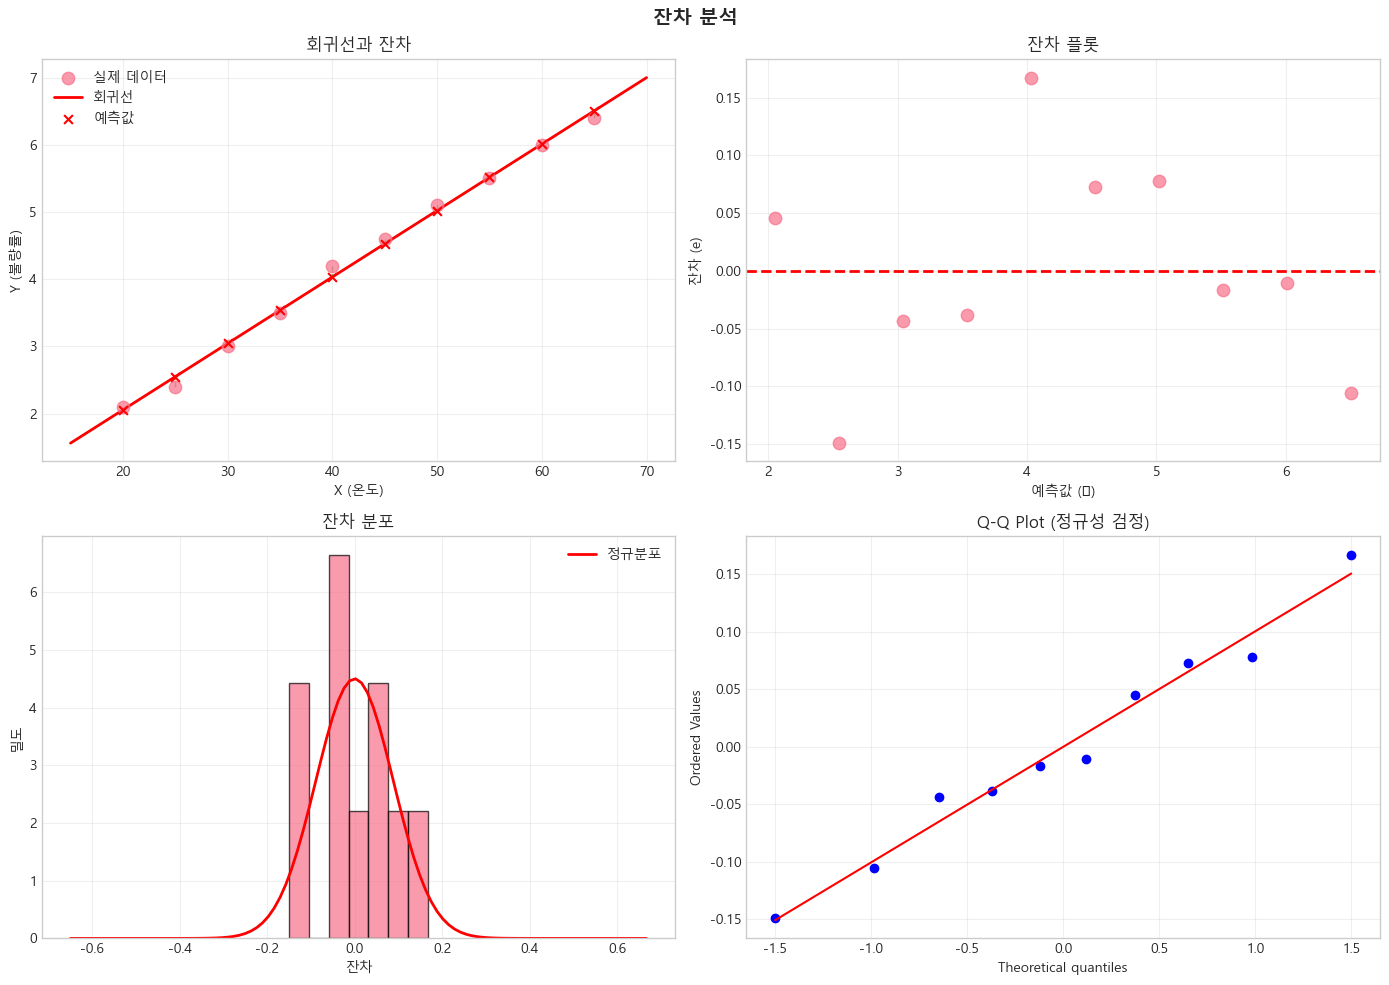


잔차 통계:
  평균: 0.000000 (0에 가까워야 함)
  표준편차: 0.088626
  최소: -0.1491
  최대: 0.1673


In [14]:
# 잔차 분석 시각화
Y_pred = model.predict(X.reshape(-1, 1))
residuals = Y - Y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 데이터와 회귀선
axes[0, 0].scatter(X, Y, s=80, alpha=0.7, label='실제 데이터', zorder=5)
X_line = np.linspace(X.min()-5, X.max()+5, 100).reshape(-1, 1)
Y_line = model.predict(X_line)
axes[0, 0].plot(X_line, Y_line, 'r-', linewidth=2, label='회귀선')

# 잔차 표시 (수직선)
for xi, yi, yi_pred in zip(X, Y, Y_pred):
    axes[0, 0].plot([xi, xi], [yi, yi_pred], 'g--', alpha=0.5, linewidth=1)
axes[0, 0].scatter(X, Y_pred, color='red', s=40, marker='x', label='예측값', zorder=6)

axes[0, 0].set_xlabel('X (온도)')
axes[0, 0].set_ylabel('Y (불량률)')
axes[0, 0].set_title('회귀선과 잔차')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. 잔차 플롯 (예측값 vs 잔차)
axes[0, 1].scatter(Y_pred, residuals, s=80, alpha=0.7)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('예측값 (Ŷ)')
axes[0, 1].set_ylabel('잔차 (e)')
axes[0, 1].set_title('잔차 플롯')
axes[0, 1].grid(True, alpha=0.3)

# 3. 잔차 히스토그램
axes[1, 0].hist(residuals, bins=7, edgecolor='black', alpha=0.7, density=True)
# 정규분포 곡선
x_norm = np.linspace(residuals.min()-0.5, residuals.max()+0.5, 100)
y_norm = stats.norm.pdf(x_norm, residuals.mean(), residuals.std())
axes[1, 0].plot(x_norm, y_norm, 'r-', linewidth=2, label='정규분포')
axes[1, 0].set_xlabel('잔차')
axes[1, 0].set_ylabel('밀도')
axes[1, 0].set_title('잔차 분포')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (정규성 검정)')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('잔차 분석', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 잔차 통계
print("\n잔차 통계:")
print(f"  평균: {residuals.mean():.6f} (0에 가까워야 함)")
print(f"  표준편차: {residuals.std():.6f}")
print(f"  최소: {residuals.min():.4f}")
print(f"  최대: {residuals.max():.4f}")

## 2.6 결정계수 ($R^2$)

### 분산의 분해

총 변동(Total Sum of Squares)은 회귀에 의해 설명되는 변동과 설명되지 않는 변동으로 분해됨:

$$
\underbrace{\sum_{i=1}^{n}(y_i - \bar{y})^2}_{SST} = \underbrace{\sum_{i=1}^{n}(\hat{y}_i - \bar{y})^2}_{SSR} + \underbrace{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{SSE}
$$

| 약어 | 명칭 | 의미 |
|------|------|------|
| **SST** | Total Sum of Squares | 총 변동 |
| **SSR** | Regression Sum of Squares | 회귀에 의해 설명된 변동 |
| **SSE** | Error Sum of Squares | 설명되지 않은 변동 (잔차) |

### 결정계수 정의

$$
R^2 = \frac{SSR}{SST} = 1 - \frac{SSE}{SST}
$$

### 해석

- **범위**: $0 \leq R^2 \leq 1$
- **의미**: 독립변수가 종속변수 변동의 몇 %를 설명하는가
- **예시**: $R^2 = 0.85$ → "온도가 불량률 변동의 85%를 설명함"

### 상관계수와의 관계

단순선형회귀에서:
$$
R^2 = r^2
$$

즉, 결정계수는 피어슨 상관계수의 제곱과 같음.

In [20]:
# R² 계산 과정 상세 설명
print("=" * 60)
print("결정계수 (R²) 계산")
print("=" * 60)

# 각 제곱합 계산
y_mean = np.mean(Y)
SST = np.sum((Y - y_mean)**2)  # 총 변동
SSR = np.sum((Y_pred - y_mean)**2)  # 회귀 변동
SSE = np.sum((Y - Y_pred)**2)  # 잔차 변동

print(f"\n[Step 1] 평균: ȳ = {y_mean:.4f}")
print(f"\n[Step 2] 제곱합 계산")
print(f"  SST (총 변동)      = Σ(yi - ȳ)²   = {SST:.4f}")
print(f"  SSR (회귀 변동)    = Σ(ŷi - ȳ)²   = {SSR:.4f}")
print(f"  SSE (잔차 변동)    = Σ(yi - ŷi)²  = {SSE:.4f}")
print(f"\n  검증: SSR + SSE = {SSR:.4f} + {SSE:.4f} = {SSR+SSE:.4f} ≈ SST ({SST:.4f})")

# R² 계산
R2_formula1 = SSR / SST
R2_formula2 = 1 - SSE / SST

print(f"\n[Step 3] R² 계산")
print(f"  R² = SSR/SST = {SSR:.4f}/{SST:.4f} = {R2_formula1:.6f}")
print(f"  R² = 1 - SSE/SST = 1 - {SSE:.4f}/{SST:.4f} = {R2_formula2:.6f}")

# sklearn 검증
from sklearn.metrics import r2_score
R2_sklearn = r2_score(Y, Y_pred)
print(f"\n  sklearn 검증: R² = {R2_sklearn:.6f}")

# 상관계수와의 관계
r = np.corrcoef(X, Y)[0, 1]
print(f"\n[관계 확인] 상관계수와 결정계수")
print(f"  r = {r:.6f}")
print(f"  r² = {r**2:.6f}")
print(f"  R² = {R2_sklearn:.6f}")
print(f"  → 단순선형회귀에서 R² = r²임을 확인")

결정계수 (R²) 계산

[Step 1] 평균: ȳ = 4.2800

[Step 2] 제곱합 계산
  SST (총 변동)      = Σ(yi - ȳ)²   = 20.2560
  SSR (회귀 변동)    = Σ(ŷi - ȳ)²   = 20.1775
  SSE (잔차 변동)    = Σ(yi - ŷi)²  = 0.0785

  검증: SSR + SSE = 20.1775 + 0.0785 = 20.2560 ≈ SST (20.2560)

[Step 3] R² 계산
  R² = SSR/SST = 20.1775/20.2560 = 0.996122
  R² = 1 - SSE/SST = 1 - 0.0785/20.2560 = 0.996122

  sklearn 검증: R² = 0.996122

[관계 확인] 상관계수와 결정계수
  r = 0.998059
  r² = 0.996122
  R² = 0.996122
  → 단순선형회귀에서 R² = r²임을 확인


## 2.7 선형회귀의 가정

선형회귀 모델이 유효하려면 다음 가정들이 충족되어야 함:

### 1. 선형성 (Linearity)
- **가정**: X와 Y의 관계가 선형임
- **확인**: 산점도에서 직선 패턴 확인
- **위반 시**: 변수 변환, 다항회귀 고려

### 2. 독립성 (Independence)
- **가정**: 관측값들이 서로 독립임 (오차 간 상관 없음)
- **확인**: Durbin-Watson 검정 (2에 가까우면 독립)
- **위반 시**: 시계열 분석 기법 사용

### 3. 등분산성 (Homoscedasticity)
- **가정**: 모든 X 값에서 오차의 분산이 동일함
- **확인**: 잔차 플롯에서 깔때기 모양 없어야 함
- **위반 시**: 가중최소제곱법(WLS), 로그 변환

### 4. 정규성 (Normality)
- **가정**: 오차가 정규분포를 따름
- **확인**: Q-Q plot, Shapiro-Wilk 검정
- **위반 시**: 표본 크기가 크면(n>30) 어느 정도 완화됨

### 추가: 다중공선성 없음 (다중회귀의 경우)
- **가정**: 독립변수들 간에 높은 상관관계가 없음
- **확인**: VIF(분산팽창계수) < 10
- **위반 시**: 변수 제거, PCA 등

# 공공데이터를 활용한 실습

## 3.1 공공데이터 소개

### 활용 데이터: 한국산업단지공단 전국산업단지현황통계

본 실습에서는 **공공데이터포털(data.go.kr)** 에서 제공하는 **한국산업단지공단_전국산업단지현황통계** 데이터를 활용함. 이 데이터는 국가승인통계(제399003호)로 신뢰성이 높으며, 분기별로 갱신됨.

#### 데이터 출처 정보

| 항목 | 내용 |
|------|------|
| **데이터명** | 한국산업단지공단_전국산업단지현황통계 |
| **제공기관** | 한국산업단지공단 |
| **승인번호** | 국가승인통계 제399003호 |
| **갱신주기** | 분기별 |
| **다운로드** | https://www.data.go.kr/data/3041272/fileData.do |
| **형식** | CSV, Excel |

### 실제 데이터 구조

전국산업단지현황통계의 컬럼 구성:

| 컬럼명 | 설명 | 데이터 타입 | 비고 |
|--------|------|-------------|------|
| 유형 | 산업단지 유형 | 문자열 | 국가/일반/도시첨단/농공 |
| 시도 | 광역시/도 | 문자열 | - |
| 시군 | 시/군/구 | 문자열 | - |
| 단지명 | 산업단지명 | 문자열 | - |
| 조성상태 | 조성 진행 상태 | 문자열 | 완료/조성중/미개발 |
| 지정면적 | 지정 면적 | 숫자(콤마) | 천㎡ |
| 관리면적 | 관리 면적 | 숫자(콤마) | 천㎡ |
| 전체면적 | 전체 면적 | 숫자(콤마) | 천㎡ |
| 분양대상 | 분양 대상 면적 | 숫자(콤마) | 천㎡ |
| 분양 | 분양 완료 면적 | 숫자(콤마) | 천㎡ |
| 미분양 | 미분양 면적 | 숫자(콤마) | 천㎡ |
| 분양률 | 분양률 | 숫자 | % |
| 입주업체 | 입주 업체 수 | 숫자(콤마) | 개사 |
| 가동업체 | 가동 업체 수 | 숫자(콤마) | 개사 |
| 고용(남) | 남성 고용 인원 | 숫자(콤마) | 명 |
| 고용(여) | 여성 고용 인원 | 숫자(콤마) | 명 |
| 고용(계) | 전체 고용 인원 | 숫자(콤마) | 명 |
| 누계생산(백만원) | 누적 생산액 | 숫자(콤마) | 백만원 |
| 누계수출(천달러) | 누적 수출액 | 숫자(콤마) | 천달러 |

## 3.2 데이터 로드 및 탐색

### 환경 설정

In [33]:
# =============================================================================
# 필요 라이브러리 임포트
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False

In [34]:
# xlsx 파일 다운로드(위 링크 참조)
#실제 데이터 파일 경로 (다운로드 후 수정 필요할 수 있음)
#!pip install openpyxl

df = pd.read_excel('한국산업단지공단_전국산업단지현황통계_20250630.xlsx')

In [35]:
df.head()

,Unnamed: 0,2025년 2분기 전국산업단지 현황통계 요약,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,(1) 조성 및 분양(천㎡),NaN,NaN,NaN,NaN,NaN,NaN,NaN,"(단위 : 개, 천㎡, %)"
2,단지유형,산업단지수,지정면적,관리면적,산업시설구역,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,전체면적,분양대상,분양,미분양,분양률(%)
4,국가,53,798306,488915,313302,286596,278206,8390,97.07


In [36]:
df = pd.read_csv('산업단지현황.csv')

In [37]:
df.head()

,유형,시도,시군,단지명,조성상태,지정면적,관리면적,전체면적,분양대상,분양,미분양,분양률,입주업체,가동업체,고용(남),고용(여),고용(계),누계생산(백만원),누계수출(천달러)
0,국가,서울,구로구,한국수출산업 (①),완료,"1,922","1,920","1,426","1,426","1,426",0,100,"15,264","13,970","93,122","43,062","136,184","8,008,695","1,472,592"
1,국가,서울,구로구,서울디지털 ①,완료,"1,922","1,920","1,426","1,426","1,426",0,100,"15,264","13,970","93,122","43,062","136,184","8,008,695","1,472,592"
2,일반,서울,구로구,서울온수,완료,158,158,123,123,123,0,100,197,197,"1,148",359,"1,507","60,000","4,000"
3,일반,서울,강서구,마곡,조성중,"1,124","1,124",729,729,603,126,83,199,149,"25,872","13,001","38,873",0,0
4,일반,서울,강동구,강동,미개발,78,78,27,0,0,0,0,0,0,0,0,0,0,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1427 entries, 0 to 1426
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0    유형          1427 non-null   object
 1    시도          1427 non-null   object
 2    시군          1427 non-null   object
 3    단지명         1427 non-null   object
 4    조성상태        1427 non-null   object
 5    지정면적        1427 non-null   object
 6    관리면적        1427 non-null   object
 7    전체면적        1427 non-null   object
 8    분양대상        1427 non-null   object
 9    분양          1427 non-null   object
 10   미분양         1427 non-null   object
 11   분양률         1427 non-null   int64 
 12   입주업체        1427 non-null   object
 13   가동업체        1427 non-null   object
 14   고용(남)       1280 non-null   object
 15   고용(여)       1280 non-null   object
 16   고용(계)       1280 non-null   object
 17   누계생산(백만원)   1280 non-null   object
 18   누계수출(천달러)   1280 non-null   object
dtypes: int64(1), object(18)
mem

In [60]:
# =============================================================================
# 핵심 전처리: 콤마가 포함된 숫자 문자열을 숫자로 변환
# =============================================================================

# 컬럼명 앞뒤 공백 제거
df.columns = df.columns.str.strip()

# 숫자형으로 변환할 컬럼 목록
numeric_columns = ['지정면적', '관리면적', '전체면적', '분양대상', '분양', '미분양','입주업체', '가동업체', '고용(남)', '고용(여)', '고용(계)','누계생산(백만원)', '누계수출(천달러)']

# 콤마 제거 및 숫자 변환
for col in numeric_columns:
    if col in df.columns:
        # 문자열인 경우 콤마 제거
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '', regex=False)
        # 숫자형으로 변환
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 결측치를 0으로 대체 (미개발 산단 등)
df[numeric_columns] = df[numeric_columns].fillna(0)

In [61]:
df.dtypes

유형            object
시도            object
시군            object
단지명           object
조성상태          object
지정면적           int64
관리면적           int64
전체면적           int64
분양대상           int64
분양             int64
미분양            int64
분양률            int64
입주업체           int64
가동업체           int64
고용(남)        float64
고용(여)        float64
고용(계)        float64
누계생산(백만원)    float64
누계수출(천달러)    float64
dtype: object

In [63]:
df.head()

,유형,시도,시군,단지명,조성상태,지정면적,관리면적,전체면적,분양대상,분양,미분양,분양률,입주업체,가동업체,고용(남),고용(여),고용(계),누계생산(백만원),누계수출(천달러)
0,국가,서울,구로구,한국수출산업 (①),완료,1922,1920,1426,1426,1426,0,100,15264,13970,93122.0,43062.0,136184.0,8008695.0,1472592.0
1,국가,서울,구로구,서울디지털 ①,완료,1922,1920,1426,1426,1426,0,100,15264,13970,93122.0,43062.0,136184.0,8008695.0,1472592.0
2,일반,서울,구로구,서울온수,완료,158,158,123,123,123,0,100,197,197,1148.0,359.0,1507.0,60000.0,4000.0
3,일반,서울,강서구,마곡,조성중,1124,1124,729,729,603,126,83,199,149,25872.0,13001.0,38873.0,0.0,0.0
4,일반,서울,강동구,강동,미개발,78,78,27,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0


In [64]:
# 데이터 타입 확인
print("\n컬럼별 데이터 타입")
print("=" * 50)
print(df.dtypes)

# 수치형 데이터 확인
print("\n\n수치형 컬럼 확인")
print("-" * 50)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"수치형 컬럼 ({len(numeric_cols)}개): {numeric_cols}")


컬럼별 데이터 타입
유형            object
시도            object
시군            object
단지명           object
조성상태          object
지정면적           int64
관리면적           int64
전체면적           int64
분양대상           int64
분양             int64
미분양            int64
분양률            int64
입주업체           int64
가동업체           int64
고용(남)        float64
고용(여)        float64
고용(계)        float64
누계생산(백만원)    float64
누계수출(천달러)    float64
dtype: object


수치형 컬럼 확인
--------------------------------------------------
수치형 컬럼 (14개): ['지정면적', '관리면적', '전체면적', '분양대상', '분양', '미분양', '분양률', '입주업체', '가동업체', '고용(남)', '고용(여)', '고용(계)', '누계생산(백만원)', '누계수출(천달러)']


### 기초 통계량 확인

In [65]:
# 분석용 수치형 컬럼
analysis_cols = ['지정면적', '관리면적', '분양률', '입주업체', '가동업체', 
                 '고용(남)', '고용(여)', '고용(계)', '누계생산(백만원)', '누계수출(천달러)']

# 기초 통계량
print("\n기초 통계량")
print("=" * 100)
stats_df = df[analysis_cols].describe()
stats_df.loc['합계'] = df[analysis_cols].sum()
stats_df.loc['결측치'] = df[analysis_cols].isnull().sum()
print(stats_df.round(2).to_string())

# 유형별 현황
print("\n\n유형별 산업단지 현황")
print("=" * 90)
type_summary = df.groupby('유형').agg({
    '단지명': 'count',
    '지정면적': 'sum',
    '입주업체': 'sum',
    '가동업체': 'sum',
    '고용(계)': 'sum',
    '누계생산(백만원)': 'sum',
    '누계수출(천달러)': 'sum'
}).rename(columns={'단지명': '단지수'})

type_summary['평균고용'] = (type_summary['고용(계)'] / type_summary['단지수']).round(0).astype(int)
print(type_summary.to_string())

# 조성상태별 현황
print("\n\n조성상태별 현황")
print("=" * 70)
status_summary = df.groupby('조성상태').agg({
    '단지명': 'count',
    '분양률': 'mean',
    '입주업체': 'sum',
    '가동업체': 'sum',
    '고용(계)': 'sum'
}).rename(columns={'단지명': '단지수', '분양률': '평균분양률'})
print(status_summary.round(1).to_string())


기초 통계량
             지정면적        관리면적        분양률       입주업체       가동업체       고용(남)      고용(여)       고용(계)     누계생산(백만원)     누계수출(천달러)
count     1427.00     1427.00    1427.00    1427.00    1427.00     1427.00    1427.00     1427.00  1.427000e+03  1.427000e+03
mean      1300.43      949.22      79.42     126.46     117.74     1548.53     462.69     2011.21  5.191034e+05  1.486826e+05
std       6405.70     3001.26      38.13     962.28     916.43     8542.20    2605.29    10994.01  3.303925e+06  1.107878e+06
min         11.00       11.00       0.00       0.00       0.00        0.00       0.00        0.00  0.000000e+00  0.000000e+00
25%        123.00      123.00      88.00       1.00       1.00        0.00       0.00        0.00  0.000000e+00  0.000000e+00
50%        250.00      248.00     100.00      12.00      10.00      149.00      45.00      205.00  1.885400e+04  1.300000e+02
75%        771.00      751.50     100.00      36.00      32.50      601.00     186.50      789.00  1.305075e+0

In [66]:
# =============================================================================
# 분석용 데이터셋 생성
# 조건: 조성 완료 & 가동업체 > 0
# =============================================================================

df_analysis = df[(df['조성상태'] == '완료') & (df['가동업체'] > 0)].copy()

print("\n분석 대상 데이터 필터링")
print("=" * 60)
print(f"전체 데이터: {len(df)}개 산업단지")
print(f"분석 대상: {len(df_analysis)}개 (조성완료 & 가동업체>0)")
print(f"제외: {len(df) - len(df_analysis)}개 (조성중/미개발 또는 가동업체=0)")

# 파생변수 생성
df_analysis['가동률'] = (df_analysis['가동업체'] / df_analysis['입주업체'] * 100).round(1)
df_analysis['업체당고용'] = (df_analysis['고용(계)'] / df_analysis['가동업체']).round(1)
df_analysis['여성고용비율'] = (df_analysis['고용(여)'] / df_analysis['고용(계)'] * 100).round(1)

print("\n파생변수 생성:")
print("  • 가동률 = 가동업체 / 입주업체 × 100")
print("  • 업체당고용 = 고용(계) / 가동업체")
print("  • 여성고용비율 = 고용(여) / 고용(계) × 100")

print(f"\n분석용 데이터 미리보기:")
display_cols = ['단지명', '유형', '시도', '가동업체', '고용(계)', '가동률', '업체당고용']
print(df_analysis[display_cols].head(10).to_string())


분석 대상 데이터 필터링
전체 데이터: 1427개 산업단지
분석 대상: 994개 (조성완료 & 가동업체>0)
제외: 433개 (조성중/미개발 또는 가동업체=0)

파생변수 생성:
  • 가동률 = 가동업체 / 입주업체 × 100
  • 업체당고용 = 고용(계) / 가동업체
  • 여성고용비율 = 고용(여) / 고용(계) × 100

분석용 데이터 미리보기:
                    단지명  유형  시도   가동업체     고용(계)    가동률  업체당고용
0            한국수출산업 (①)  국가  서울  13970  136184.0   91.5    9.7
1               서울디지털 ①  국가  서울  13970  136184.0   91.5    9.7
2                  서울온수  일반  서울    197    1507.0  100.0    7.6
5         명지·녹산 (① + ②)  국가  부산   1287   26618.0   82.4   20.7
6          녹산지구(산업단지) ①  국가  부산   1287   26618.0   82.4   20.7
8          부산과학 (① + ②)  일반  부산    237    4889.0  100.0   20.6
9                부산과학 ①  일반  부산    225    3822.0  100.0   17.0
10            지사(외국인) ②  일반  부산     12    1067.0  100.0   88.9
11  부산신항배후국제산업물류도시(1단계)  일반  부산    536   10362.0   98.3   19.3
12                   명례  일반  부산    109    1886.0   94.8   17.3


## 3.3 탐색적 데이터 분석 (EDA)

### 3.3.1 변수 분포 시각화

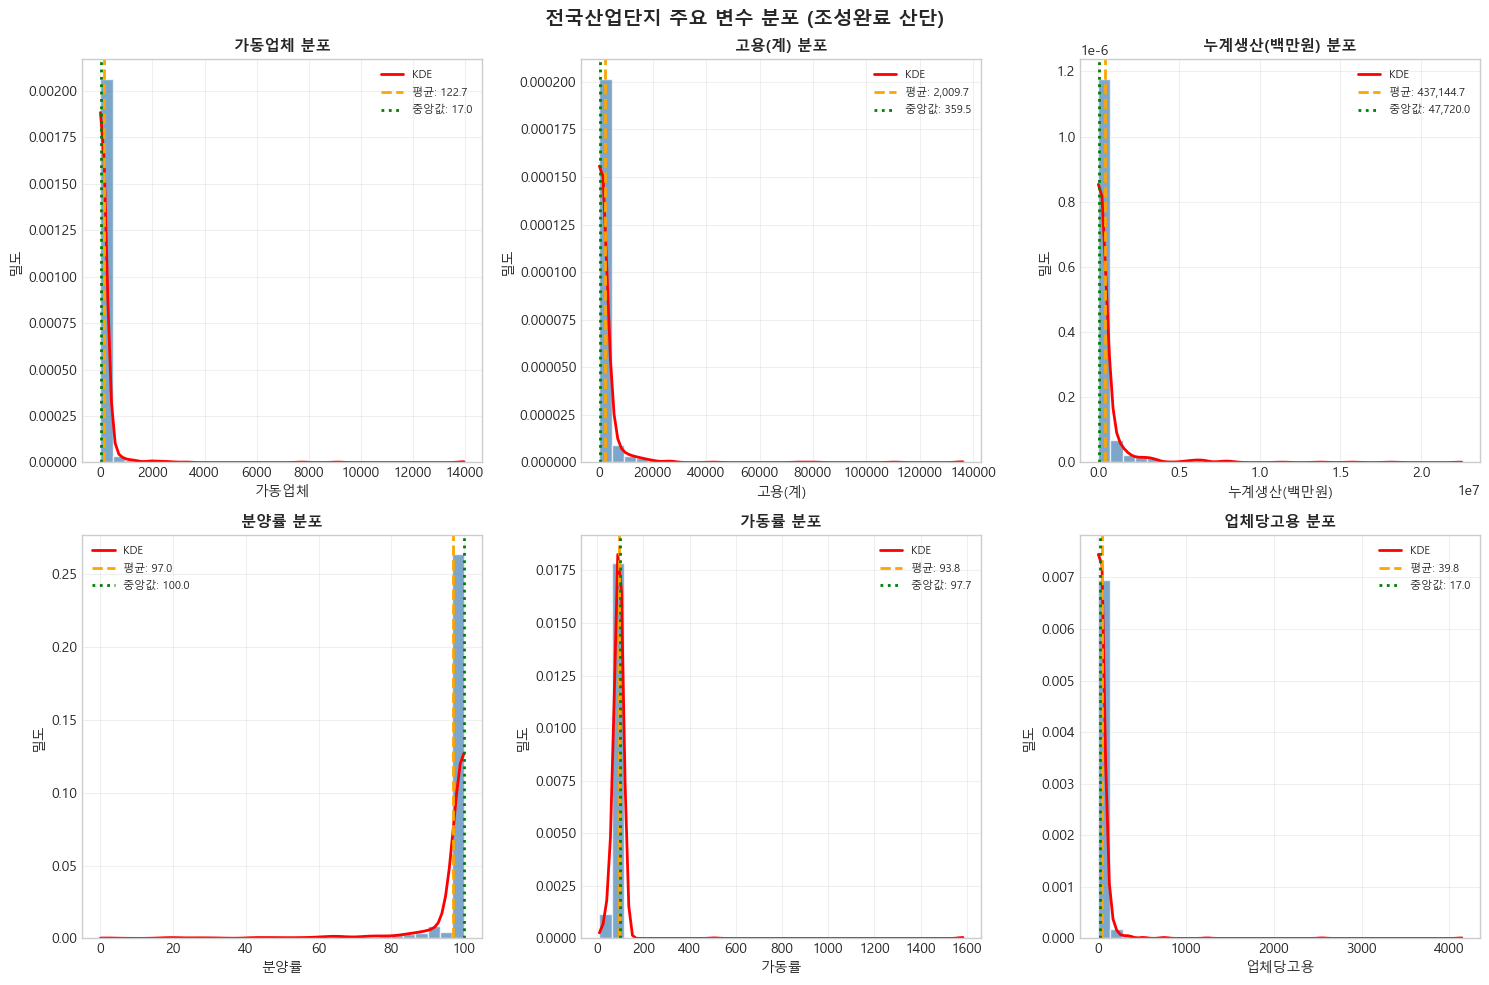

In [67]:
# 주요 변수 분포 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_vars = ['가동업체', '고용(계)', '누계생산(백만원)', '분양률', '가동률', '업체당고용']

for idx, col in enumerate(plot_vars):
    ax = axes[idx]
    data = df_analysis[col]
    
    # 히스토그램 + KDE
    ax.hist(data, bins=30, density=True, alpha=0.7, edgecolor='white', color='steelblue')
    
    if data.std() > 0:
        kde_x = np.linspace(data.min(), data.max(), 100)
        kde = stats.gaussian_kde(data)
        ax.plot(kde_x, kde(kde_x), 'r-', linewidth=2, label='KDE')
    
    # 평균, 중앙값 표시
    ax.axvline(x=data.mean(), color='orange', linestyle='--', linewidth=2, label=f'평균: {data.mean():,.1f}')
    ax.axvline(x=data.median(), color='green', linestyle=':', linewidth=2, label=f'중앙값: {data.median():,.1f}')
    
    ax.set_title(f'{col} 분포', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('밀도')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('전국산업단지 주요 변수 분포 (조성완료 산단)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

###  상관행렬 분석

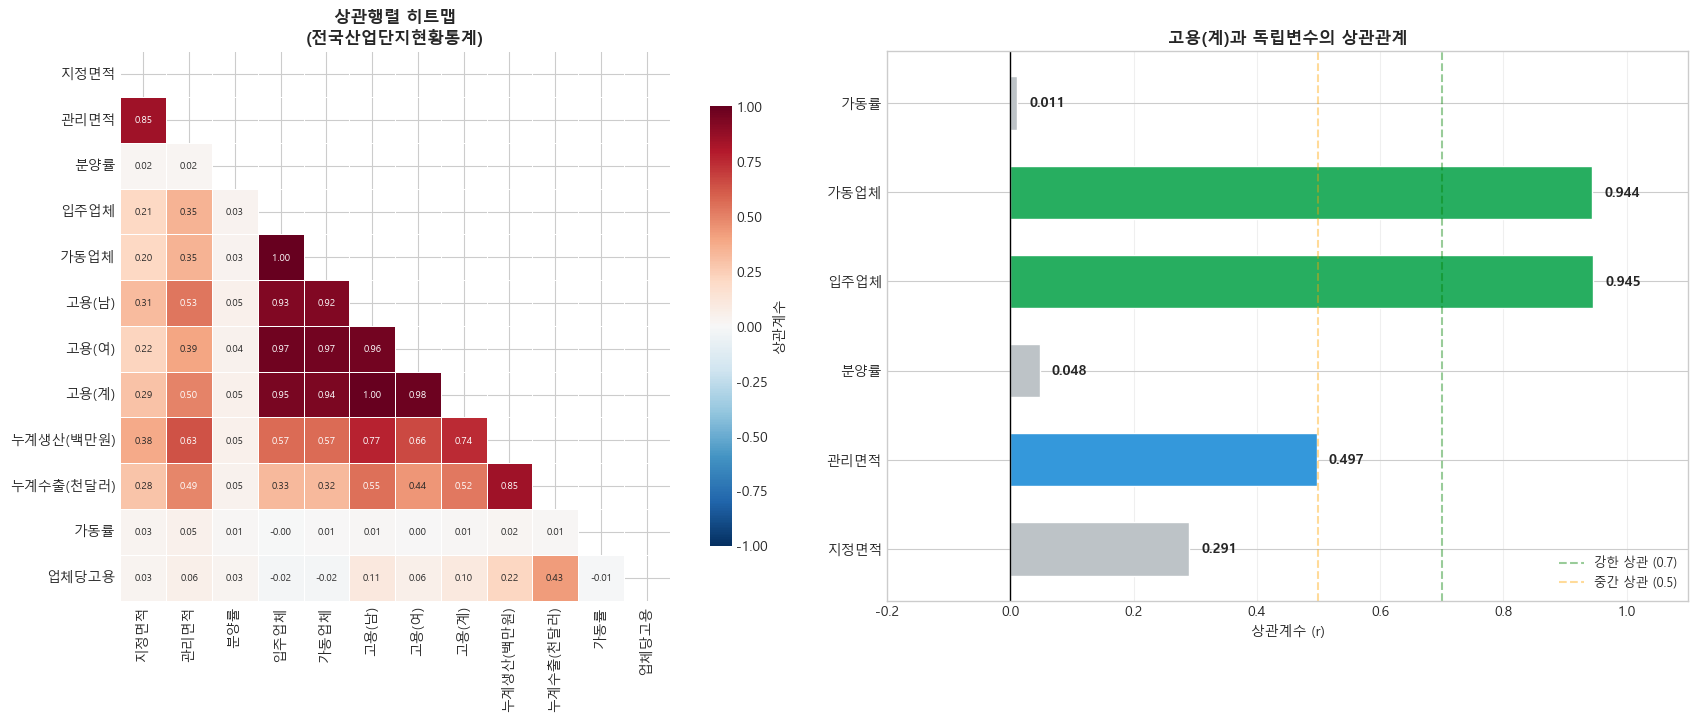


고용(계)과 각 변수의 상관관계 해석
  지정면적           : r = +0.2907 (미미한 양의 상관)
  관리면적           : r = +0.4972 (★ 약한 양의 상관)
  분양률            : r = +0.0476 (미미한 양의 상관)
  입주업체           : r = +0.9455 (★★★ 강한 양의 상관)
  가동업체           : r = +0.9439 (★★★ 강한 양의 상관)
  가동률            : r = +0.0109 (미미한 양의 상관)


In [69]:
# 분석 대상 변수
corr_vars = ['지정면적', '관리면적', '분양률', '입주업체', '가동업체', 
             '고용(남)', '고용(여)', '고용(계)', '누계생산(백만원)', '누계수출(천달러)',
             '가동률', '업체당고용']

# 상관행렬 계산
corr_matrix = df_analysis[corr_vars].corr()

# 상관행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. 전체 상관행렬 히트맵 (하삼각)
ax = axes[0]
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            vmin=-1, 
            vmax=1,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': '상관계수'},
            annot_kws={'size': 7},
            ax=ax)
ax.set_title('상관행렬 히트맵\n(전국산업단지현황통계)', fontsize=12, fontweight='bold')

# 2. 고용(계)과 주요 변수의 상관관계 막대그래프
ax = axes[1]
target = '고용(계)'
features = ['지정면적', '관리면적', '분양률', '입주업체', '가동업체', '가동률']
correlations = [corr_matrix.loc[target, f] for f in features]

# 색상: 상관계수 크기에 따라
colors = ['#27ae60' if abs(c) >= 0.7 else '#f39c12' if abs(c) >= 0.5 else '#3498db' if abs(c) >= 0.3 else '#bdc3c7' for c in correlations]

bars = ax.barh(features, correlations, color=colors, edgecolor='white', height=0.6)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.4, label='강한 상관 (0.7)')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.4, label='중간 상관 (0.5)')

# 값 표시
for bar, c in zip(bars, correlations):
    ax.text(c + 0.02 if c >= 0 else c - 0.08, bar.get_y() + bar.get_height()/2,
            f'{c:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(-0.2, 1.1)
ax.set_xlabel('상관계수 (r)')
ax.set_title(f'{target}과 독립변수의 상관관계', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# 상관관계 해석 출력
print("\n고용(계)과 각 변수의 상관관계 해석")
print("=" * 70)
for f, c in zip(features, correlations):
    if abs(c) >= 0.7:
        strength = "★★★ 강한"
    elif abs(c) >= 0.5:
        strength = "★★ 중간"
    elif abs(c) >= 0.3:
        strength = "★ 약한"
    else:
        strength = "미미한"
    direction = "양의" if c > 0 else "음의"
    print(f"  {f:15s}: r = {c:+.4f} ({strength} {direction} 상관)")

### 통계적 유의성 검정

In [70]:
# 상관계수 통계적 검정
print("\n상관계수 통계적 유의성 검정")
print("=" * 90)
print(f"{'변수':<18} {'상관계수(r)':>12} {'t-통계량':>12} {'p-value':>18} {'유의성':>10}")
print("-" * 90)

target = '고용(계)'
n = len(df_analysis)

for feature in features:
    r, p_value = stats.pearsonr(df_analysis[feature], df_analysis[target])
    
    # t-통계량 계산
    if abs(r) < 1:
        t_stat = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)
    else:
        t_stat = np.inf
    
    # 유의수준 표시
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "n.s."
    
    print(f"  {feature:<16} {r:>12.4f} {t_stat:>12.4f} {p_value:>18.2e} {sig:>10}")

print("-" * 90)
print("유의수준: *** p<0.001, ** p<0.01, * p<0.05, n.s. 유의하지 않음")
print(f"표본크기: n = {n}")


상관계수 통계적 유의성 검정
변수                      상관계수(r)        t-통계량            p-value        유의성
------------------------------------------------------------------------------------------
  지정면적                   0.2907       9.5704           8.16e-21        ***
  관리면적                   0.4972      18.0472           3.52e-63        ***
  분양률                    0.0476       1.4997           1.34e-01       n.s.
  입주업체                   0.9455      91.4323           0.00e+00        ***
  가동업체                   0.9439      90.0346           0.00e+00        ***
  가동률                    0.0109       0.3434           7.31e-01       n.s.
------------------------------------------------------------------------------------------
유의수준: *** p<0.001, ** p<0.01, * p<0.05, n.s. 유의하지 않음
표본크기: n = 994


## 3.4 단순선형회귀 분석: 가동업체 → 고용(계)

상관분석 결과, **가동업체**가 **고용(계)** 와 가장 높은 상관관계를 보임. 이를 대상으로 단순선형회귀 분석 수행.

In [73]:
print("=" * 70)
print("                    단순선형회귀 분석 개요")
print("=" * 70)
print()
print("연구 질문:")
print("  '산업단지의 가동업체 수가 증가하면 고용 인원이 얼마나 증가하는가?'")
print()
print("분석 설계:")
print("  • 독립변수 (X): 가동업체 (개사)")
print("  • 종속변수 (Y): 고용(계) (명)")
print("  • 분석 방법: 최소자승법(OLS) 기반 단순선형회귀")
print("  • 데이터 출처: 한국산업단지공단 전국산업단지현황통계")
print()

# 변수 설정
X = df_analysis['가동업체'].values
y = df_analysis['고용(계)'].values

# 사전 상관분석
r, p_value = stats.pearsonr(X, y)

print("사전 상관분석 결과:")
print(f"  • 피어슨 상관계수 (r): {r:.4f}")
print(f"  • 결정계수 (r²): {r**2:.4f}")
print(f"  • p-value: {p_value:.2e}")

if r >= 0.9:
    interpretation = "매우 강한 양의 상관관계"
elif r >= 0.7:
    interpretation = "강한 양의 상관관계"
elif r >= 0.5:
    interpretation = "중간 수준의 양의 상관관계"
else:
    interpretation = "약한 상관관계"
print(f"  • 해석: {interpretation}")

                    단순선형회귀 분석 개요

연구 질문:
  '산업단지의 가동업체 수가 증가하면 고용 인원이 얼마나 증가하는가?'

분석 설계:
  • 독립변수 (X): 가동업체 (개사)
  • 종속변수 (Y): 고용(계) (명)
  • 분석 방법: 최소자승법(OLS) 기반 단순선형회귀
  • 데이터 출처: 한국산업단지공단 전국산업단지현황통계

사전 상관분석 결과:
  • 피어슨 상관계수 (r): 0.9439
  • 결정계수 (r²): 0.8910
  • p-value: 0.00e+00
  • 해석: 매우 강한 양의 상관관계


### 데이터 분할

In [74]:
# 훈련/테스트 데이터 분할 (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X.reshape(-1, 1), y, 
    test_size=0.2, 
    random_state=42
)

print("\n데이터 분할 결과")
print("=" * 60)
print(f"  전체 데이터: {len(X)}개 산업단지")
print(f"  훈련 데이터: {len(X_train)}개 ({len(X_train)/len(X)*100:.0f}%)")
print(f"  테스트 데이터: {len(X_test)}개 ({len(X_test)/len(X)*100:.0f}%)")
print()
print(f"  훈련 데이터 - 가동업체 범위: {X_train.min():,.0f} ~ {X_train.max():,.0f} 개사")
print(f"  훈련 데이터 - 고용(계) 범위: {y_train.min():,.0f} ~ {y_train.max():,.0f} 명")


데이터 분할 결과
  전체 데이터: 994개 산업단지
  훈련 데이터: 795개 (80%)
  테스트 데이터: 199개 (20%)

  훈련 데이터 - 가동업체 범위: 1 ~ 13,970 개사
  훈련 데이터 - 고용(계) 범위: 0 ~ 136,184 명


In [75]:
# 선형회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 회귀계수
beta_0 = model.intercept_
beta_1 = model.coef_[0]

print("\n" + "=" * 70)
print("                    단순선형회귀 모델 결과")
print("=" * 70)
print()
print("추정된 회귀계수:")
print(f"  β₀ (절편)   : {beta_0:,.2f}")
print(f"  β₁ (기울기) : {beta_1:.4f}")
print()
print("회귀식:")
print(f"  고용(계) = {beta_0:,.2f} + {beta_1:.4f} × 가동업체")
print()
print("해석:")
print(f"  • 가동업체가 0개일 때 기대 고용: {beta_0:,.0f}명 (절편, 이론적 값)")
print(f"  • 가동업체 1개 증가 시 → 고용 평균 {beta_1:.2f}명 증가")
print(f"  • 가동업체 10개 증가 시 → 고용 평균 {beta_1*10:,.0f}명 증가")
print(f"  • 가동업체 100개 증가 시 → 고용 평균 {beta_1*100:,.0f}명 증가")


                    단순선형회귀 모델 결과

추정된 회귀계수:
  β₀ (절편)   : 709.05
  β₁ (기울기) : 10.3119

회귀식:
  고용(계) = 709.05 + 10.3119 × 가동업체

해석:
  • 가동업체가 0개일 때 기대 고용: 709명 (절편, 이론적 값)
  • 가동업체 1개 증가 시 → 고용 평균 10.31명 증가
  • 가동업체 10개 증가 시 → 고용 평균 103명 증가
  • 가동업체 100개 증가 시 → 고용 평균 1,031명 증가


In [76]:
# 예측
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 평가 함수
def evaluate_model(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - 2)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    # MAPE (0 제외)
    non_zero = y_true != 0
    mape = np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100
    return {'R²': r2, 'Adj_R²': adj_r2, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

train_metrics = evaluate_model(y_train, y_train_pred)
test_metrics = evaluate_model(y_test, y_test_pred)

print("\n" + "=" * 80)
print("                           모델 평가 결과")
print("=" * 80)
print()
print(f"{'평가 지표':<18} {'훈련 데이터':>18} {'테스트 데이터':>18} {'설명':>22}")
print("-" * 80)
print(f"{'R² (결정계수)':<18} {train_metrics['R²']:>18.4f} {test_metrics['R²']:>18.4f} {'설명력':>22}")
print(f"{'Adjusted R²':<18} {train_metrics['Adj_R²']:>18.4f} {test_metrics['Adj_R²']:>18.4f} {'조정 설명력':>22}")
print(f"{'RMSE (명)':<18} {train_metrics['RMSE']:>18,.0f} {test_metrics['RMSE']:>18,.0f} {'평균제곱근오차':>22}")
print(f"{'MAE (명)':<18} {train_metrics['MAE']:>18,.0f} {test_metrics['MAE']:>18,.0f} {'평균절대오차':>22}")
print(f"{'MAPE (%)':<18} {train_metrics['MAPE']:>18.2f} {test_metrics['MAPE']:>18.2f} {'평균절대%오차':>22}")
print("-" * 80)

print("\n결과 해석:")
print(f"  • R² = {test_metrics['R²']:.4f}")
print(f"    → 가동업체 수가 고용(계) 변동의 {test_metrics['R²']*100:.1f}%를 설명함")
print(f"  • RMSE = {test_metrics['RMSE']:,.0f}명")
print(f"    → 예측값과 실제값의 평균적 오차")
print(f"  • MAPE = {test_metrics['MAPE']:.2f}%")
print(f"    → 평균적으로 {test_metrics['MAPE']:.1f}%의 예측 오차")

# 과적합 진단
overfit = abs(train_metrics['R²'] - test_metrics['R²'])
print(f"\n과적합 진단:")
print(f"  • 훈련-테스트 R² 차이: {overfit:.4f}")
print(f"    → {'과적합 없음 (양호)' if overfit < 0.05 else '과적합 가능성 있음'}")


                           모델 평가 결과

평가 지표                          훈련 데이터            테스트 데이터                     설명
--------------------------------------------------------------------------------
R² (결정계수)                      0.9023             0.5718                    설명력
Adjusted R²                    0.9021             0.5696                 조정 설명력
RMSE (명)                        2,910              2,296                평균제곱근오차
MAE (명)                         1,127              1,187                 평균절대오차
MAPE (%)                       289.16             312.17                평균절대%오차
--------------------------------------------------------------------------------

결과 해석:
  • R² = 0.5718
    → 가동업체 수가 고용(계) 변동의 57.2%를 설명함
  • RMSE = 2,296명
    → 예측값과 실제값의 평균적 오차
  • MAPE = 312.17%
    → 평균적으로 312.2%의 예측 오차

과적합 진단:
  • 훈련-테스트 R² 차이: 0.3305
    → 과적합 가능성 있음


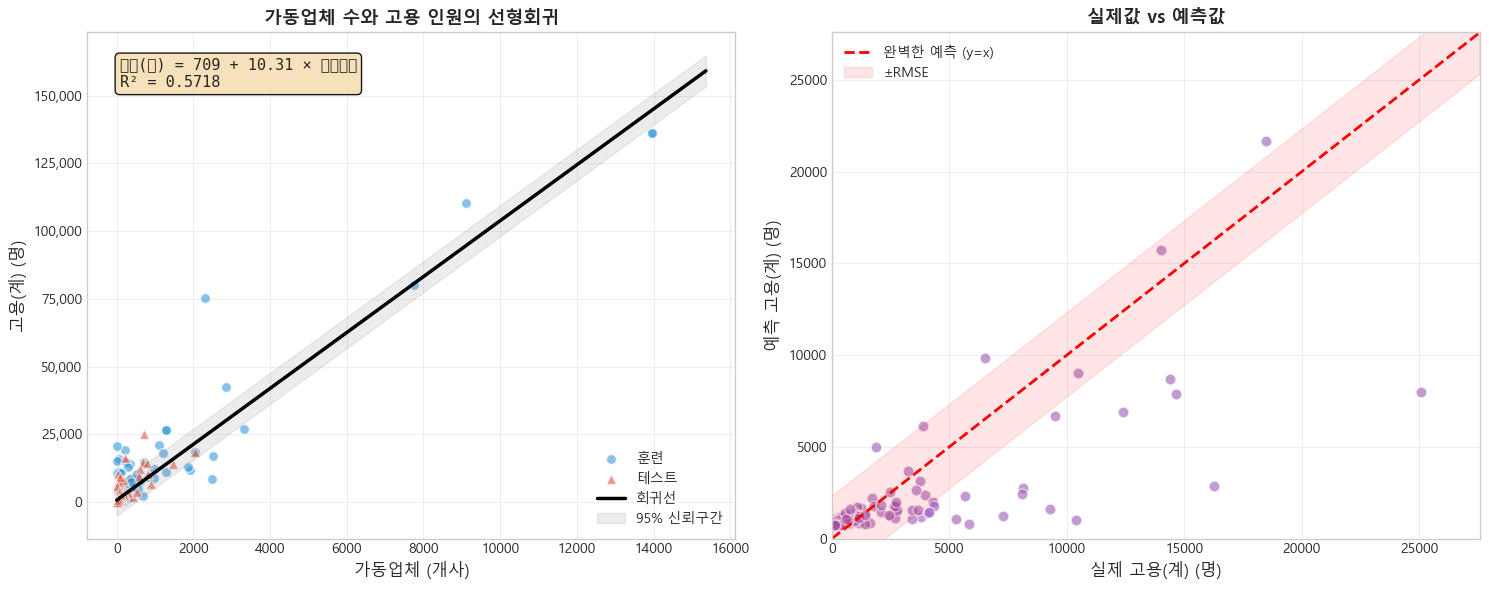

In [77]:
# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. 회귀선
ax = axes[0]
ax.scatter(X_train, y_train, alpha=0.6, s=50, c='#3498db', label='훈련', edgecolor='white')
ax.scatter(X_test, y_test, alpha=0.6, s=50, c='#e74c3c', marker='^', label='테스트', edgecolor='white')

# 회귀선
X_line = np.linspace(0, X.max() * 1.1, 100).reshape(-1, 1)
y_line = model.predict(X_line)
ax.plot(X_line, y_line, 'k-', linewidth=2.5, label='회귀선', zorder=5)

# 95% 신뢰구간
se = np.sqrt(mean_squared_error(y_train, y_train_pred))
ax.fill_between(X_line.flatten(), y_line - 1.96*se, y_line + 1.96*se, 
                alpha=0.15, color='gray', label='95% 신뢰구간')

# 회귀식 표시
eq_text = f'고용(계) = {beta_0:,.0f} + {beta_1:.2f} × 가동업체\nR² = {test_metrics["R²"]:.4f}'
ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))

ax.set_xlabel('가동업체 (개사)', fontsize=12)
ax.set_ylabel('고용(계) (명)', fontsize=12)
ax.set_title('가동업체 수와 고용 인원의 선형회귀', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))

# 2. 실제 vs 예측
ax = axes[1]
ax.scatter(y_test, y_test_pred, alpha=0.6, s=60, c='#9b59b6', edgecolor='white')

lims = [min(y_test.min(), y_test_pred.min()) * 0.9, 
        max(y_test.max(), y_test_pred.max()) * 1.1]
ax.plot(lims, lims, 'r--', linewidth=2, label='완벽한 예측 (y=x)')
ax.fill_between(lims, 
                [lims[0]-test_metrics['RMSE'], lims[1]-test_metrics['RMSE']], 
                [lims[0]+test_metrics['RMSE'], lims[1]+test_metrics['RMSE']], 
                alpha=0.1, color='red', label=f'±RMSE')

ax.set_xlabel('실제 고용(계) (명)', fontsize=12)
ax.set_ylabel('예측 고용(계) (명)', fontsize=12)
ax.set_title('실제값 vs 예측값', fontsize=13, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(lims)
ax.set_ylim(lims)

plt.tight_layout()
plt.show()

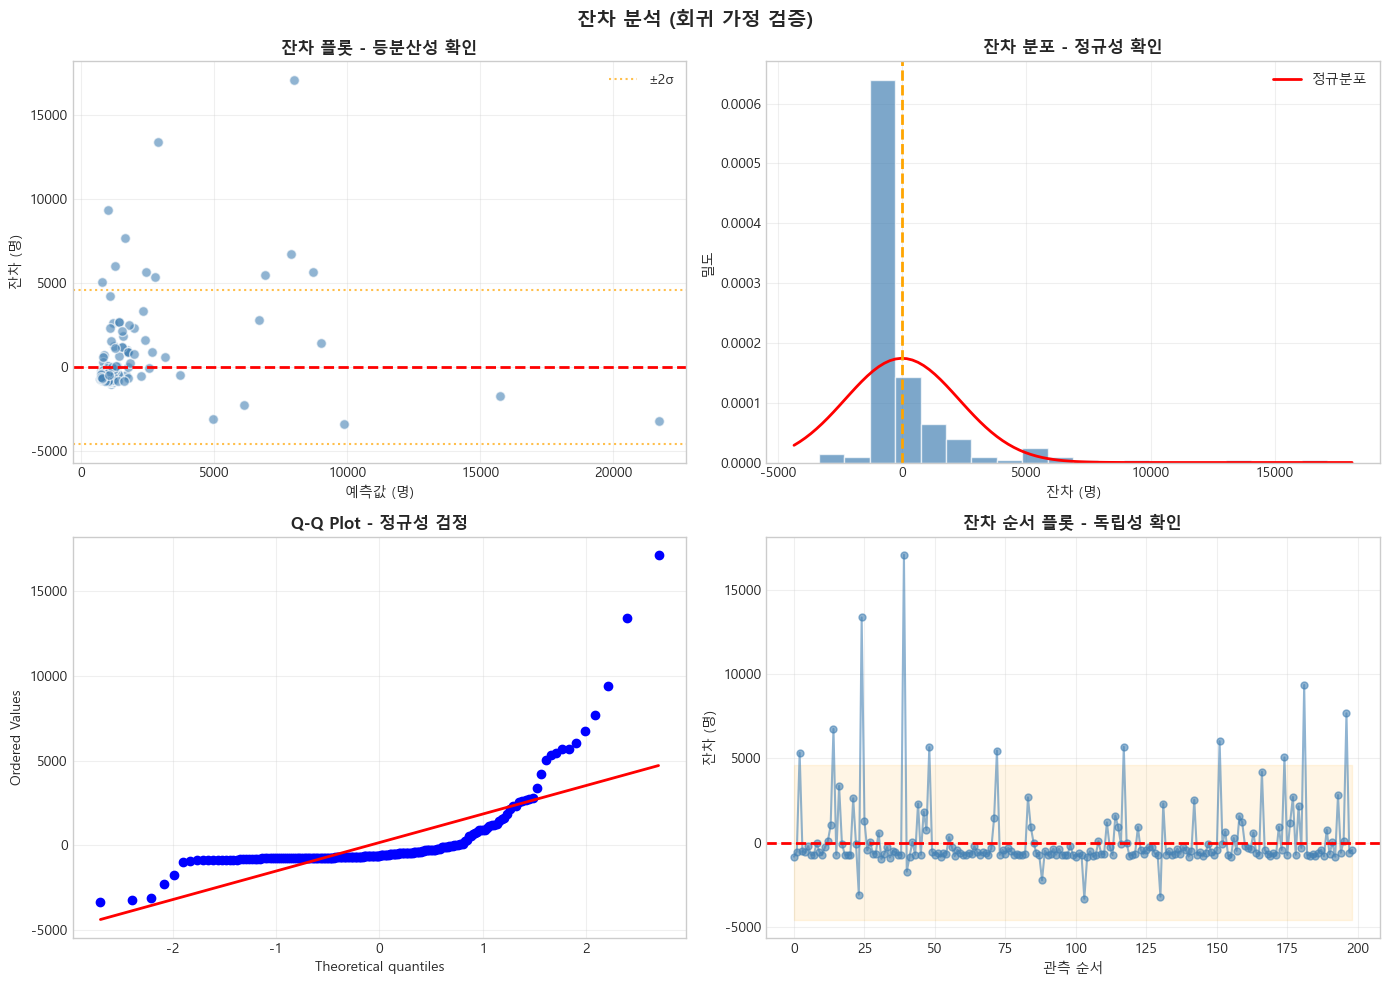


잔차 진단 결과
  • 잔차 평균: 174.83 (0에 가까워야 함)
  • 잔차 표준편차: 2,289.65
  • 왜도: 4.0116
  • 첨도: 20.9583

Shapiro-Wilk 정규성 검정:
  • 통계량: 0.5358, p-value: 0.0000
  • 결론: 정규성 위반 가능성

Durbin-Watson 통계량: 2.1441
  • 결론: 독립성 만족


In [78]:
# 잔차 계산
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 잔차 플롯
ax = axes[0, 0]
ax.scatter(y_test_pred, residuals, alpha=0.6, s=50, c='steelblue', edgecolor='white')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.axhline(y=2*residuals.std(), color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axhline(y=-2*residuals.std(), color='orange', linestyle=':', linewidth=1.5, alpha=0.7, label='±2σ')
ax.set_xlabel('예측값 (명)')
ax.set_ylabel('잔차 (명)')
ax.set_title('잔차 플롯 - 등분산성 확인', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. 잔차 히스토그램
ax = axes[0, 1]
ax.hist(residuals, bins=20, density=True, alpha=0.7, edgecolor='white', color='steelblue')
x_norm = np.linspace(residuals.min()-1000, residuals.max()+1000, 100)
ax.plot(x_norm, stats.norm.pdf(x_norm, 0, residuals.std()), 'r-', linewidth=2, label='정규분포')
ax.axvline(x=0, color='orange', linestyle='--', linewidth=2)
ax.set_xlabel('잔차 (명)')
ax.set_ylabel('밀도')
ax.set_title('잔차 분포 - 정규성 확인', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Q-Q Plot
ax = axes[1, 0]
stats.probplot(residuals, dist="norm", plot=ax)
ax.set_title('Q-Q Plot - 정규성 검정', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.get_lines()[1].set_color('red')
ax.get_lines()[1].set_linewidth(2)

# 4. 잔차 순서 플롯
ax = axes[1, 1]
ax.plot(range(len(residuals)), residuals, 'o-', alpha=0.6, markersize=5, color='steelblue')
ax.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax.fill_between(range(len(residuals)), -2*residuals.std(), 2*residuals.std(), alpha=0.1, color='orange')
ax.set_xlabel('관측 순서')
ax.set_ylabel('잔차 (명)')
ax.set_title('잔차 순서 플롯 - 독립성 확인', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.suptitle('잔차 분석 (회귀 가정 검증)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 잔차 통계
print("\n잔차 진단 결과")
print("=" * 60)
print(f"  • 잔차 평균: {residuals.mean():,.2f} (0에 가까워야 함)")
print(f"  • 잔차 표준편차: {residuals.std():,.2f}")
print(f"  • 왜도: {stats.skew(residuals):.4f}")
print(f"  • 첨도: {stats.kurtosis(residuals):.4f}")

# Shapiro-Wilk 검정
if len(residuals) <= 5000:
    sw_stat, sw_p = stats.shapiro(residuals)
    print(f"\nShapiro-Wilk 정규성 검정:")
    print(f"  • 통계량: {sw_stat:.4f}, p-value: {sw_p:.4f}")
    print(f"  • 결론: {'정규성 만족' if sw_p > 0.05 else '정규성 위반 가능성'}")

# Durbin-Watson
dw = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
print(f"\nDurbin-Watson 통계량: {dw:.4f}")
print(f"  • 결론: {'독립성 만족' if 1.5 <= dw <= 2.5 else '자기상관 가능성'}")

## 3.5 예측 및 역예측

In [79]:
# 새로운 가동업체 수에서 고용 예측
new_companies = np.array([[50], [100], [200], [500], [1000], [3000], [5000], [10000]])
predictions = model.predict(new_companies)

print("=" * 80)
print("                      신규 산업단지 고용 인원 예측")
print("=" * 80)
print()
print(f"{'가동업체':>12} {'예측 고용(계)':>18} {'95% 신뢰구간':>30} {'규모':>12}")
print("-" * 80)

se = np.sqrt(mean_squared_error(y_test, y_test_pred))

for comp, pred in zip(new_companies.flatten(), predictions):
    lower = max(0, pred - 1.96 * se)
    upper = pred + 1.96 * se
    
    if comp < 100:
        scale = "소규모"
    elif comp < 500:
        scale = "중규모"
    elif comp < 2000:
        scale = "대규모"
    else:
        scale = "초대형"
    
    print(f"{comp:>12,} 개사 {pred:>18,.0f} 명  [{lower:>12,.0f} ~ {upper:>12,.0f}] {scale:>12}")

print("-" * 80)
print("* 95% 신뢰구간 = 예측값 ± 1.96 × 표준오차")

                      신규 산업단지 고용 인원 예측

        가동업체           예측 고용(계)                       95% 신뢰구간           규모
--------------------------------------------------------------------------------
          50 개사              1,225 명  [           0 ~        5,725]          소규모
         100 개사              1,740 명  [           0 ~        6,241]          중규모
         200 개사              2,771 명  [           0 ~        7,272]          중규모
         500 개사              5,865 명  [       1,364 ~       10,366]          대규모
       1,000 개사             11,021 명  [       6,520 ~       15,522]          대규모
       3,000 개사             31,645 명  [      27,144 ~       36,145]          초대형
       5,000 개사             52,268 명  [      47,768 ~       56,769]          초대형
      10,000 개사            103,828 명  [      99,327 ~      108,329]          초대형
--------------------------------------------------------------------------------
* 95% 신뢰구간 = 예측값 ± 1.96 × 표준오차


In [81]:
# 역예측 함수
def inverse_predict(target_y, intercept, slope):
    return (target_y - intercept) / slope

# 목표 고용 시나리오
targets = [5000, 10000, 30000, 50000, 100000, 200000]

print("\n" + "=" * 80)
print("                   목표 고용 달성을 위한 역예측")
print("=" * 80)
print()
print(f"회귀식: 고용(계) = {beta_0:,.0f} + {beta_1:.4f} × 가동업체")
print(f"역산식: 가동업체 = (고용(계) - {beta_0:,.0f}) / {beta_1:.4f}")
print()
print(f"{'목표 고용(명)':>18} {'필요 가동업체(개사)':>22} {'현실성':>15} {'비고':>18}")
print("-" * 80)

min_comp, max_comp = X.min(), X.max()

for target in targets:
    required = inverse_predict(target, beta_0, beta_1)
    
    if required < 0:
        feasibility = "불가"
        note = "음수 (비현실적)"
    elif required <= max_comp:
        feasibility = "실현가능"
        note = "현재 데이터 범위 내"
    elif required <= max_comp * 2:
        feasibility = "도전적"
        note = "대규모 산단 필요"
    else:
        feasibility = "외삽주의"
        note = "데이터 범위 크게 초과"
    
    print(f"{target:>18,} 명 {required:>22,.0f} 개사 {feasibility:>15} {note:>18}")

print("-" * 80)
print(f"* 현재 데이터 가동업체 범위: {min_comp:,.0f} ~ {max_comp:,.0f} 개사")
print(f"* 범위 외 예측(인터폴레이션)은 신뢰도가 낮음")


                   목표 고용 달성을 위한 역예측

회귀식: 고용(계) = 709 + 10.3119 × 가동업체
역산식: 가동업체 = (고용(계) - 709) / 10.3119

          목표 고용(명)            필요 가동업체(개사)             현실성                 비고
--------------------------------------------------------------------------------
             5,000 명                    416 개사            실현가능        현재 데이터 범위 내
            10,000 명                    901 개사            실현가능        현재 데이터 범위 내
            30,000 명                  2,841 개사            실현가능        현재 데이터 범위 내
            50,000 명                  4,780 개사            실현가능        현재 데이터 범위 내
           100,000 명                  9,629 개사            실현가능        현재 데이터 범위 내
           200,000 명                 19,326 개사             도전적          대규모 산단 필요
--------------------------------------------------------------------------------
* 현재 데이터 가동업체 범위: 1 ~ 13,970 개사
* 범위 외 예측(인터폴레이션)은 신뢰도가 낮음



시도별 가동업체 ↔ 고용(계) 상관관계
시도  산단수     상관계수       p-value
제주    5 0.997970  1.097621e-04
대전    5 0.997107  1.866898e-04
경북  120 0.992825 1.074209e-110
인천   15 0.984549  3.202940e-11
경기  131 0.969868  5.594262e-81
전남   83 0.919312  1.496260e-34
광주   14 0.881447  3.090266e-05
충북  104 0.864033  3.604868e-32
부산   34 0.852692  1.538050e-10
울산   21 0.840087  1.892898e-06
전북   88 0.792697  3.517605e-20
세종   12 0.761108  4.036867e-03
대구   19 0.727684  4.134597e-04
강원   66 0.566730  7.029120e-07
경남  141 0.552719  1.193206e-12
충남  133 0.361828  1.874576e-05


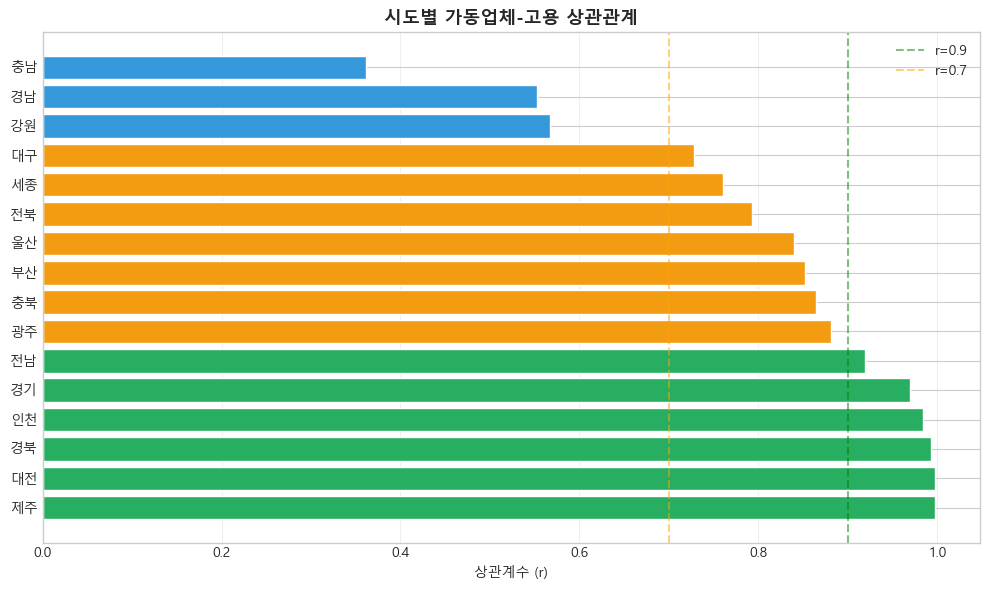

In [82]:
# 시도별 가동업체-고용 상관관계
print("\n시도별 가동업체 ↔ 고용(계) 상관관계")
print("=" * 65)

region_results = []
for region in df_analysis['시도'].unique():
    subset = df_analysis[df_analysis['시도'] == region]
    if len(subset) >= 5:
        r, p = stats.pearsonr(subset['가동업체'], subset['고용(계)'])
        region_results.append({'시도': region, '산단수': len(subset), 
                              '상관계수': r, 'p-value': p})

region_df = pd.DataFrame(region_results).sort_values('상관계수', ascending=False)
print(region_df.to_string(index=False))

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if r >= 0.9 else '#f39c12' if r >= 0.7 else '#3498db' 
          for r in region_df['상관계수']]
ax.barh(region_df['시도'], region_df['상관계수'], color=colors, edgecolor='white')
ax.axvline(x=0.9, color='green', linestyle='--', alpha=0.5, label='r=0.9')
ax.axvline(x=0.7, color='orange', linestyle='--', alpha=0.5, label='r=0.7')
ax.set_xlabel('상관계수 (r)')
ax.set_title('시도별 가동업체-고용 상관관계', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


유형별 회귀분석 결과

국가산업단지:
  • 산단 수: 45개
  • 회귀식: 고용 = 2,994 + 10.06 × 가동업체
  • R²: 0.9329
  • 해석: 가동업체 1개당 평균 10.1명 고용

일반산업단지:
  • 산단 수: 489개
  • 회귀식: 고용 = 1,142 + 10.38 × 가동업체
  • R²: 0.5003
  • 해석: 가동업체 1개당 평균 10.4명 고용


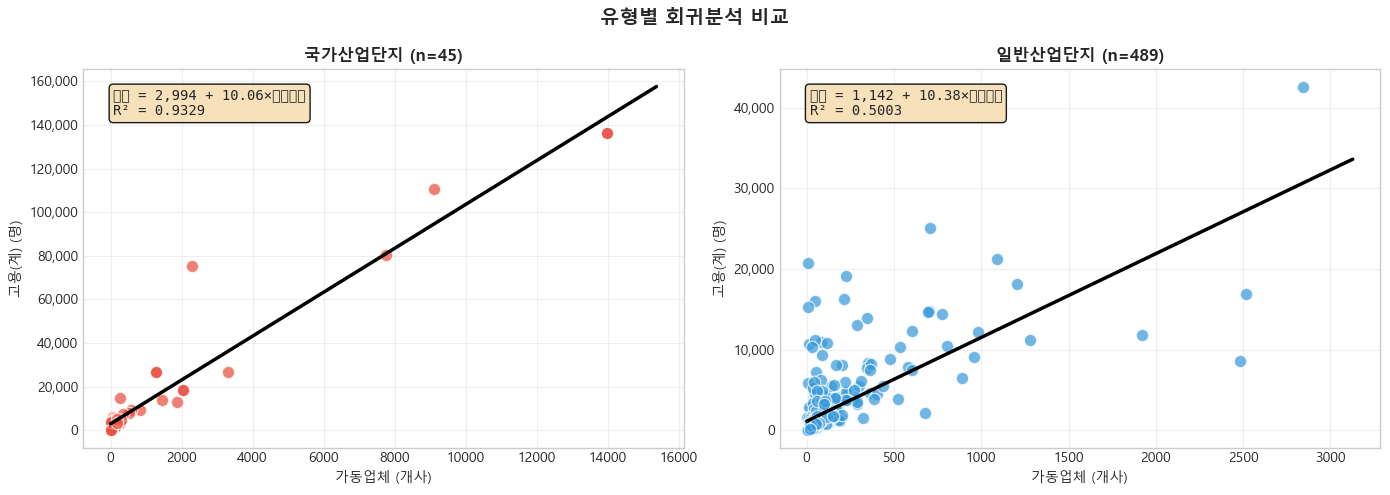

In [83]:
# 유형별 회귀분석
print("\n유형별 회귀분석 결과")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, 유형 in enumerate(['국가', '일반']):
    subset = df_analysis[df_analysis['유형'] == 유형]
    
    if len(subset) >= 5:
        X_sub = subset['가동업체'].values.reshape(-1, 1)
        y_sub = subset['고용(계)'].values
        
        model_sub = LinearRegression()
        model_sub.fit(X_sub, y_sub)
        y_pred_sub = model_sub.predict(X_sub)
        r2_sub = r2_score(y_sub, y_pred_sub)
        
        ax = axes[idx]
        ax.scatter(X_sub, y_sub, alpha=0.7, s=80, 
                   c='#e74c3c' if 유형=='국가' else '#3498db', edgecolor='white')
        
        X_line = np.linspace(X_sub.min()*0.9, X_sub.max()*1.1, 100).reshape(-1, 1)
        y_line = model_sub.predict(X_line)
        ax.plot(X_line, y_line, 'k-', linewidth=2.5)
        
        eq = f'고용 = {model_sub.intercept_:,.0f} + {model_sub.coef_[0]:.2f}×가동업체\nR² = {r2_sub:.4f}'
        ax.text(0.05, 0.95, eq, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
        
        ax.set_xlabel('가동업체 (개사)')
        ax.set_ylabel('고용(계) (명)')
        ax.set_title(f'{유형}산업단지 (n={len(subset)})', fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
        
        print(f"\n{유형}산업단지:")
        print(f"  • 산단 수: {len(subset)}개")
        print(f"  • 회귀식: 고용 = {model_sub.intercept_:,.0f} + {model_sub.coef_[0]:.2f} × 가동업체")
        print(f"  • R²: {r2_sub:.4f}")
        print(f"  • 해석: 가동업체 1개당 평균 {model_sub.coef_[0]:.1f}명 고용")

plt.suptitle('유형별 회귀분석 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. 학습 정리

## 핵심 개념 요약

### 상관분석

| 개념 | 수식 | 범위 |
|------|------|------|
| 피어슨 상관계수 | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$ | -1 ~ +1 |

**해석 기준:**
- \|r\| ≥ 0.9: 매우 강한 상관
- \|r\| ≥ 0.7: 강한 상관
- \|r\| ≥ 0.5: 중간 상관
- \|r\| ≥ 0.3: 약한 상관
- \|r\| < 0.3: 미미한 상관

### 단순선형회귀

| 개념 | 수식 | 설명 |
|------|------|------|
| 회귀식 | $\hat{Y} = \beta_0 + \beta_1 X$ | X로 Y 예측 |
| 결정계수 | $R^2 = 1 - \frac{SSE}{SST}$ | 모델 설명력 (0~1) |

---

## 데이터 전처리 패턴

```python
# 콤마 포함 숫자 변환 (실제 공공데이터 로드 시 필수)
numeric_cols = ['지정면적', '관리면적', '입주업체', '가동업체', 
                '고용(남)', '고용(여)', '고용(계)', 
                '누계생산(백만원)', '누계수출(천달러)']

for col in numeric_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '')
    df[col] = pd.to_numeric(df[col], errors='coerce')
```

---

## 실습해볼만한 내용들

### 과제 1: 생산액 예측
- 종속변수를 `누계생산(백만원)`으로 변경하여 분석

### 과제 2: 시도별 모델 비교
- 경기도, 경북, 경남 각각의 회귀모델 생성 및 비교